# Re-Deriving the Branching Ratio 
...of eta -> mu+ mu- gamma, from the 1980 analysis paper  


**Author**: Michael Peters  

### Define constants and data

In [85]:
import numpy as np
from scipy.optimize import curve_fit
import scipy.integrate as integrate
import matplotlib.pyplot as plt
from tabulate import tabulate
import math
import matplotlib as mpl

# Set DPI for high-resolution figures
mpl.rcParams['figure.dpi'] = 300

# Alternate constants (from pdg)
ALPHA = 1. / 137. # m_Z mass scale
M_ETA_PDG = 0.547862  # GeV/c^2
M_ETA = .54867  # digitized from paper
M_MU = .1056583745  # from pdg
BR_ETA2GG =.3941  # from pdg
prefactor = (2 * ALPHA) / (3 * np.pi) * BR_ETA2GG

In [86]:
# Digitized data from plot in paper
x = np.array([0.04994, 0.06962, 0.08918, 0.10887, 0.12889, 0.14895, 0.16888,
              0.18911, 0.2188])
y = np.array([1.13117, 0.96908, 1.30802, 1.54427, 1.91811, 1.82588, 1.60247,
              3.21721, 2.55531])
ybar = [1.34043, 1.13093, 1.57283, 1.71686, 2.14894, 2.08674, 1.89034, 3.86088,
        3.23895]  # upper error bars
yerr = np.subtract(ybar, y)  # y errors

# Parameters from paper
LAMBDA0 = [.72, .09]  # from paper; [value, uncertainty]
# K is a nuisance parameter that is only used to fit a value of Lambda to the data.
# Once Lambda is fit, K does not go into the integral which calculates the BR.
K0 = .9089376019880376  # digitized from Fig. 2; [value]



### Define FormFactor class

In [87]:
class FormFactor:
    def __init__(self, alpha=ALPHA, m_eta=M_ETA, m_mu=M_MU, br_eta2gg=BR_ETA2GG, Lambda0=LAMBDA0, K0=K0):
        self.alpha = alpha
        self.m_eta = m_eta
        self.m_mu = m_mu
        self.br_eta2gg = br_eta2gg
        self.q2_min = (2 * self.m_mu)**2
        self.q2_max = self.m_eta**2
        self.prefactor = (2 * self.alpha) / (3 * np.pi) * self.br_eta2gg
        self.Lambda0 = Lambda0
        self.K0 = K0

    # =============================================================================

    def F(self, x, Lambda):
        """Form factor of the eta meson in the pole approximation (paper Eq. 5).

        The pole model is:
            F(q^2; 0) = (1 - q^2/Λ^2)^(-1)

        Args:
            x (float): q^2 = m^2_{μμ}
            Lambda (float): pole parameter Λ

        Returns:
            float: F(q^2; 0)
        """
        return (1.0 - x / Lambda**2) ** (-1)

    # =============================================================================

    def F2(self, x, Lambda, K=1.0):
        """Squared form factor F^2(q^2; 0).

        Note: experimental points for F^2 are often fit with an extra overall
        normalization factor:
            F^2(q^2; 0) = K * (1 - q^2/Λ^2)^(-2)
        where K absorbs normalization uncertainty.

        Args:
            x (float): q^2 = m^2_{μμ}
            Lambda (float): pole parameter Λ
            K (float): overall normalization factor for F^2 (default 1)

        Returns:
            float: F^2(q^2; 0) (optionally scaled by K)
        """
        return K * (1.0 - x / (Lambda**2))**(-2)

    # =============================================================================

    def fit(self, x, y, yerr=None, fit_Lambda=True, fit_K=True):
        """Fit wrapper for scipy's curve_fit() which allows for choice of free
        parameters.

        Args:
            x (list): x values from data in plot
            y (list): y values from data in plot
            yerr (np.array, optional): y error values from data in plot. Defaults
                to None.
            fit_Lambda (bool, optional): _description_. Defaults to True.
            fit_K (bool, optional): _description_. Defaults to True.

        Returns:
            dict (string, float): Lambda and K fit results, including errors.
        """
        # For all fixed values.
        if not fit_Lambda and not fit_K:
            return {'Lambda': self.Lambda0[0], 
                    'Lambda_err': self.Lambda0[1],
                    'K': K0, 
                    'K_err': 0.0}
        if fit_Lambda and fit_K:
            def fnc(x, Lambda, K): return self.F2(x, Lambda, K)
            bounds = ([0.0, 0.0], [np.inf, np.inf])
        elif fit_Lambda and not fit_K:
            def fnc(x, Lambda): return self.F2(x, Lambda, K0)
            bounds = ([0.0], [np.inf])
        elif not fit_Lambda and fit_K:
            def fnc(x, K): return self.F2(x, self.Lambda0[0], K)
            bounds = ([0.0], [np.inf])

        # Ensure all data is numpy array
        popt, pcov = curve_fit(fnc, np.array(x), np.array(y), 
                               sigma=np.array(yerr), absolute_sigma=True)
        perr = np.sqrt(np.diag(pcov))

        # Convert to float values
        popt = [float(v) for v in popt]
        perr = [float(v) for v in perr]

        result = {}
        idx = 0
        if fit_Lambda:
            result['Lambda'] = popt[idx]
            result['Lambda_err'] = perr[idx]
            idx += 1
        else:
            result['Lambda'] = self.Lambda0[0]
            result['Lambda_err'] = self.Lambda0[1]
        if fit_K:
            result['K'] = popt[idx]
            result['K_err'] = perr[idx]
            idx += 1
        else:
            result['K'] = K0
            result['K_err'] = 0.0

        return result

    # =============================================================================

    def integrand(self, q2, Lambda):
        """Integrand of the eta form factor integral over q2. Eqn. 4 from the
        paper.

        Args:
            q2 (float): q^2 = m^2_{μμ}
            Lambda (float): pole parameter Λ

        Returns:
            float: integrand value
        """
        # Kinematic limits
        if q2 < self.q2_min or q2 > self.q2_max: return 0.0

        term1 = (1 - q2 / self.m_eta**2)**3
        term2 = (1 + 2 * self.m_mu**2 / q2)
        term3 = np.sqrt(1 - 4 * self.m_mu**2 / q2)
        term4 = abs(self.F(q2, Lambda))**2
        return term1 * term2 * term3 * term4 / q2

    # =============================================================================

    def integrate(self, Lambda, bounds=None):
        """Calculate form factor integral.

        Args:
            Lambda (float): Parameter value
            bounds (list (float, float)): (Optional) Custom bounds of integration.
                Default bounds of integration are [self.q2_min, self.q2_max].

        Returns:
            (float, float): integral value and its numerical uncertainty
        """
        if bounds is None: bounds = [self.q2_min, self.q2_max]

        # Pass points of possible divergence into `quad`, which then handles any
        # difficulties in convergence.
        points = []
        if bounds[0] < Lambda**2 < bounds[1]: points.append(Lambda**2)

        return integrate.quad(
            lambda q2: self.integrand(q2, Lambda),
            bounds[0],
            bounds[1],
            points=points,
        )

    # =============================================================================

    def branching_ratio(self, Lambda, bounds=None):
        """Calculate the branching ratio.

        Args:
            Lambda (float): Lambda parameter value

        Returns:
            list (float, float): List of branching ratio and its uncertainty value
        """
        int_val, _ = self.integrate(Lambda, bounds=bounds)
        return self.prefactor * int_val

In [88]:
# ff = FormFactor(alpha=alpha_mz, m_eta=m_eta_pdg)
ff = FormFactor()

In [89]:
fits = []
fit_Lambda = [True, False]
fit_K = [True, False]
table = []

for i in range(2):
    for j in range(2):
        fit = {'fit_Lambda': fit_Lambda[i], 'fit_K': fit_K[j]}
        fit.update(ff.fit(x, y, yerr, fit_Lambda=fit_Lambda[i], fit_K=fit_K[j]))
        fits.append(fit)

for fit in fits:
    table.append((fit['fit_Lambda'], fit['fit_K'], 
                  f"{fit['Lambda']:.2f}", f"{fit['Lambda_err']:.2f}", 
                  f"{fit['K']:.2f}", f"{fit['K_err']:.2f}"))

headers = ['fit Λ', 'fit K', 'Λ', 'ΔΛ', 'K', 'ΔK']
print(tabulate(table, headers, tablefmt="github"))

| fit Λ   | fit K   |    Λ |   ΔΛ |    K |   ΔK |
|---------|---------|------|------|------|------|
| True    | True    | 0.7  | 0.05 | 0.87 | 0.11 |
| True    | False   | 0.72 | 0.03 | 0.91 | 0    |
| False   | True    | 0.72 | 0.09 | 0.9  | 0.05 |
| False   | False   | 0.72 | 0.09 | 0.91 | 0    |


In [90]:
table = []
for fit in fits:
    int_val, int_err = ff.integrate(fit['Lambda'])
    br = ff.branching_ratio(fit['Lambda'])

    print(f"fit Lambda = {fit['fit_Lambda']}, fit K = {fit['fit_K']}:")
    print(f"integral = {int_val:.3f} ± {int_err:.0e}")
    print(f"BR = {br * 1e4:.2f}e-4\n")

    table.append((
        str(fit['fit_Lambda']),
        str(fit['fit_K']),
        f"{br * 1e4:.2f}e-4"
    ))

headers = ['fit Λ', 'fit K', 'BR']
print(tabulate(table, headers, tablefmt="github"))

fit Lambda = True, fit K = True:
integral = 0.550 ± 7e-09
BR = 3.36e-4

fit Lambda = True, fit K = False:
integral = 0.535 ± 7e-09
BR = 3.27e-4

fit Lambda = False, fit K = True:
integral = 0.534 ± 7e-09
BR = 3.26e-4

fit Lambda = False, fit K = False:
integral = 0.534 ± 7e-09
BR = 3.26e-4

| fit Λ   | fit K   |       BR |
|---------|---------|----------|
| True    | True    | 0.000336 |
| True    | False   | 0.000327 |
| False   | True    | 0.000326 |
| False   | False   | 0.000326 |


### Plot Fits

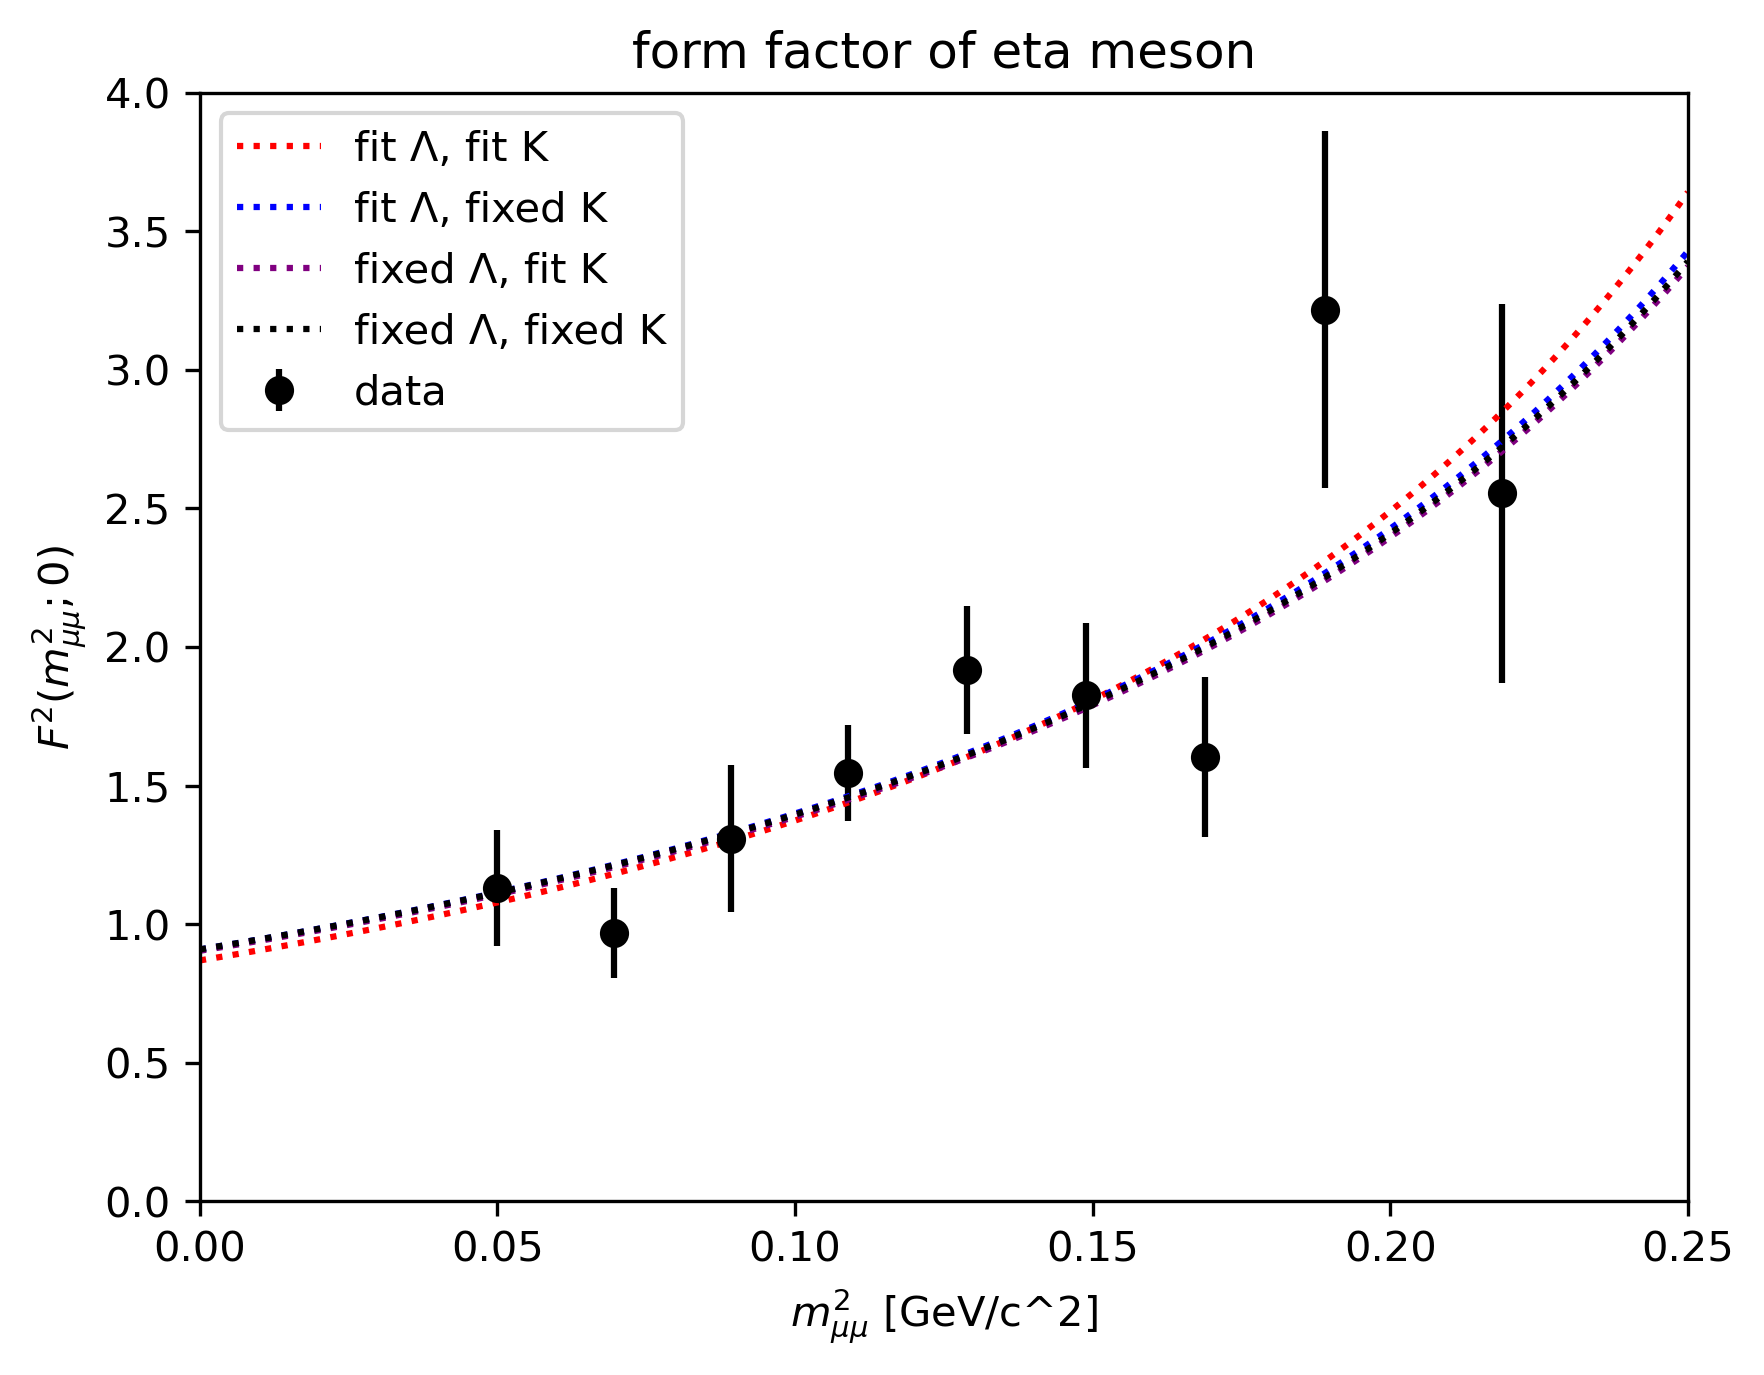

In [91]:
# Plot data with error bars and the fitted curve
plt.errorbar(x, y, yerr=yerr, fmt='o', color='black', label='data')
xx = np.linspace(0, 0.25, 400)
plt.plot(xx, ff.F2(xx, fits[0]['Lambda'], fits[0]['K']), ':', color='red',
            label=f"fit Λ, fit K")
plt.plot(xx, ff.F2(xx, fits[1]['Lambda'], fits[1]['K']), ':', color='blue',
            label=f"fit Λ, fixed K")
plt.plot(xx, ff.F2(xx, fits[2]['Lambda'], fits[2]['K']), ':', color='purple',
            label=f"fixed Λ, fit K")
plt.plot(xx, ff.F2(xx, fits[3]['Lambda'], fits[3]['K']), ':', color='black',
            label=f"fixed Λ, fixed K")
plt.legend()
plt.xlim(0, .25)
plt.ylim(0, 4)
plt.xlabel(r"$m^2_{\mu\mu}$ [GeV/c^2]")
plt.ylabel(r"$F^2(m^2_{\mu\mu}; 0)$")
plt.title("form factor of eta meson")
plt.show()


These fits are all in very close agreement, deviating most significantly at the tail end (which is expected given the greater variance and fewer data points).

## Uncertainty Propagation

### Method I: Numerical Propagation

Here, we sample `n` values of Λ normally distributed about its mean, with standard deviation $\sigma_\Lambda$.

For each Λ sampled, we compute the branching ratio. We then collect all these branching ratio values and find their mean and standard deviation.

In [92]:
ff = FormFactor()
n = 10000
Lambdas = np.random.normal(LAMBDA0[0], LAMBDA0[1], size=n)

br_values = []
for Lambda in Lambdas:
    # The integral diverges as Lambda^2 approaches q2_max, so we only consider
    # values of Lambda that are above the pole.
    if Lambda**2 < ff.q2_max: continue
    int_val, int_err = ff.integrate(Lambda)
    br = ff.branching_ratio(Lambda)
    br_values.append(br)

br_values = np.array(br_values)
br_mean = np.mean(br_values)
dbr  = np.std(br_values)
print(f"BR = ({br_mean * 10000.:.2f} ± {dbr * 10000.:.2f})e-4")

BR = (3.34 ± 0.44)e-4


The result is in agreement with previous calculations (somewhat too high).

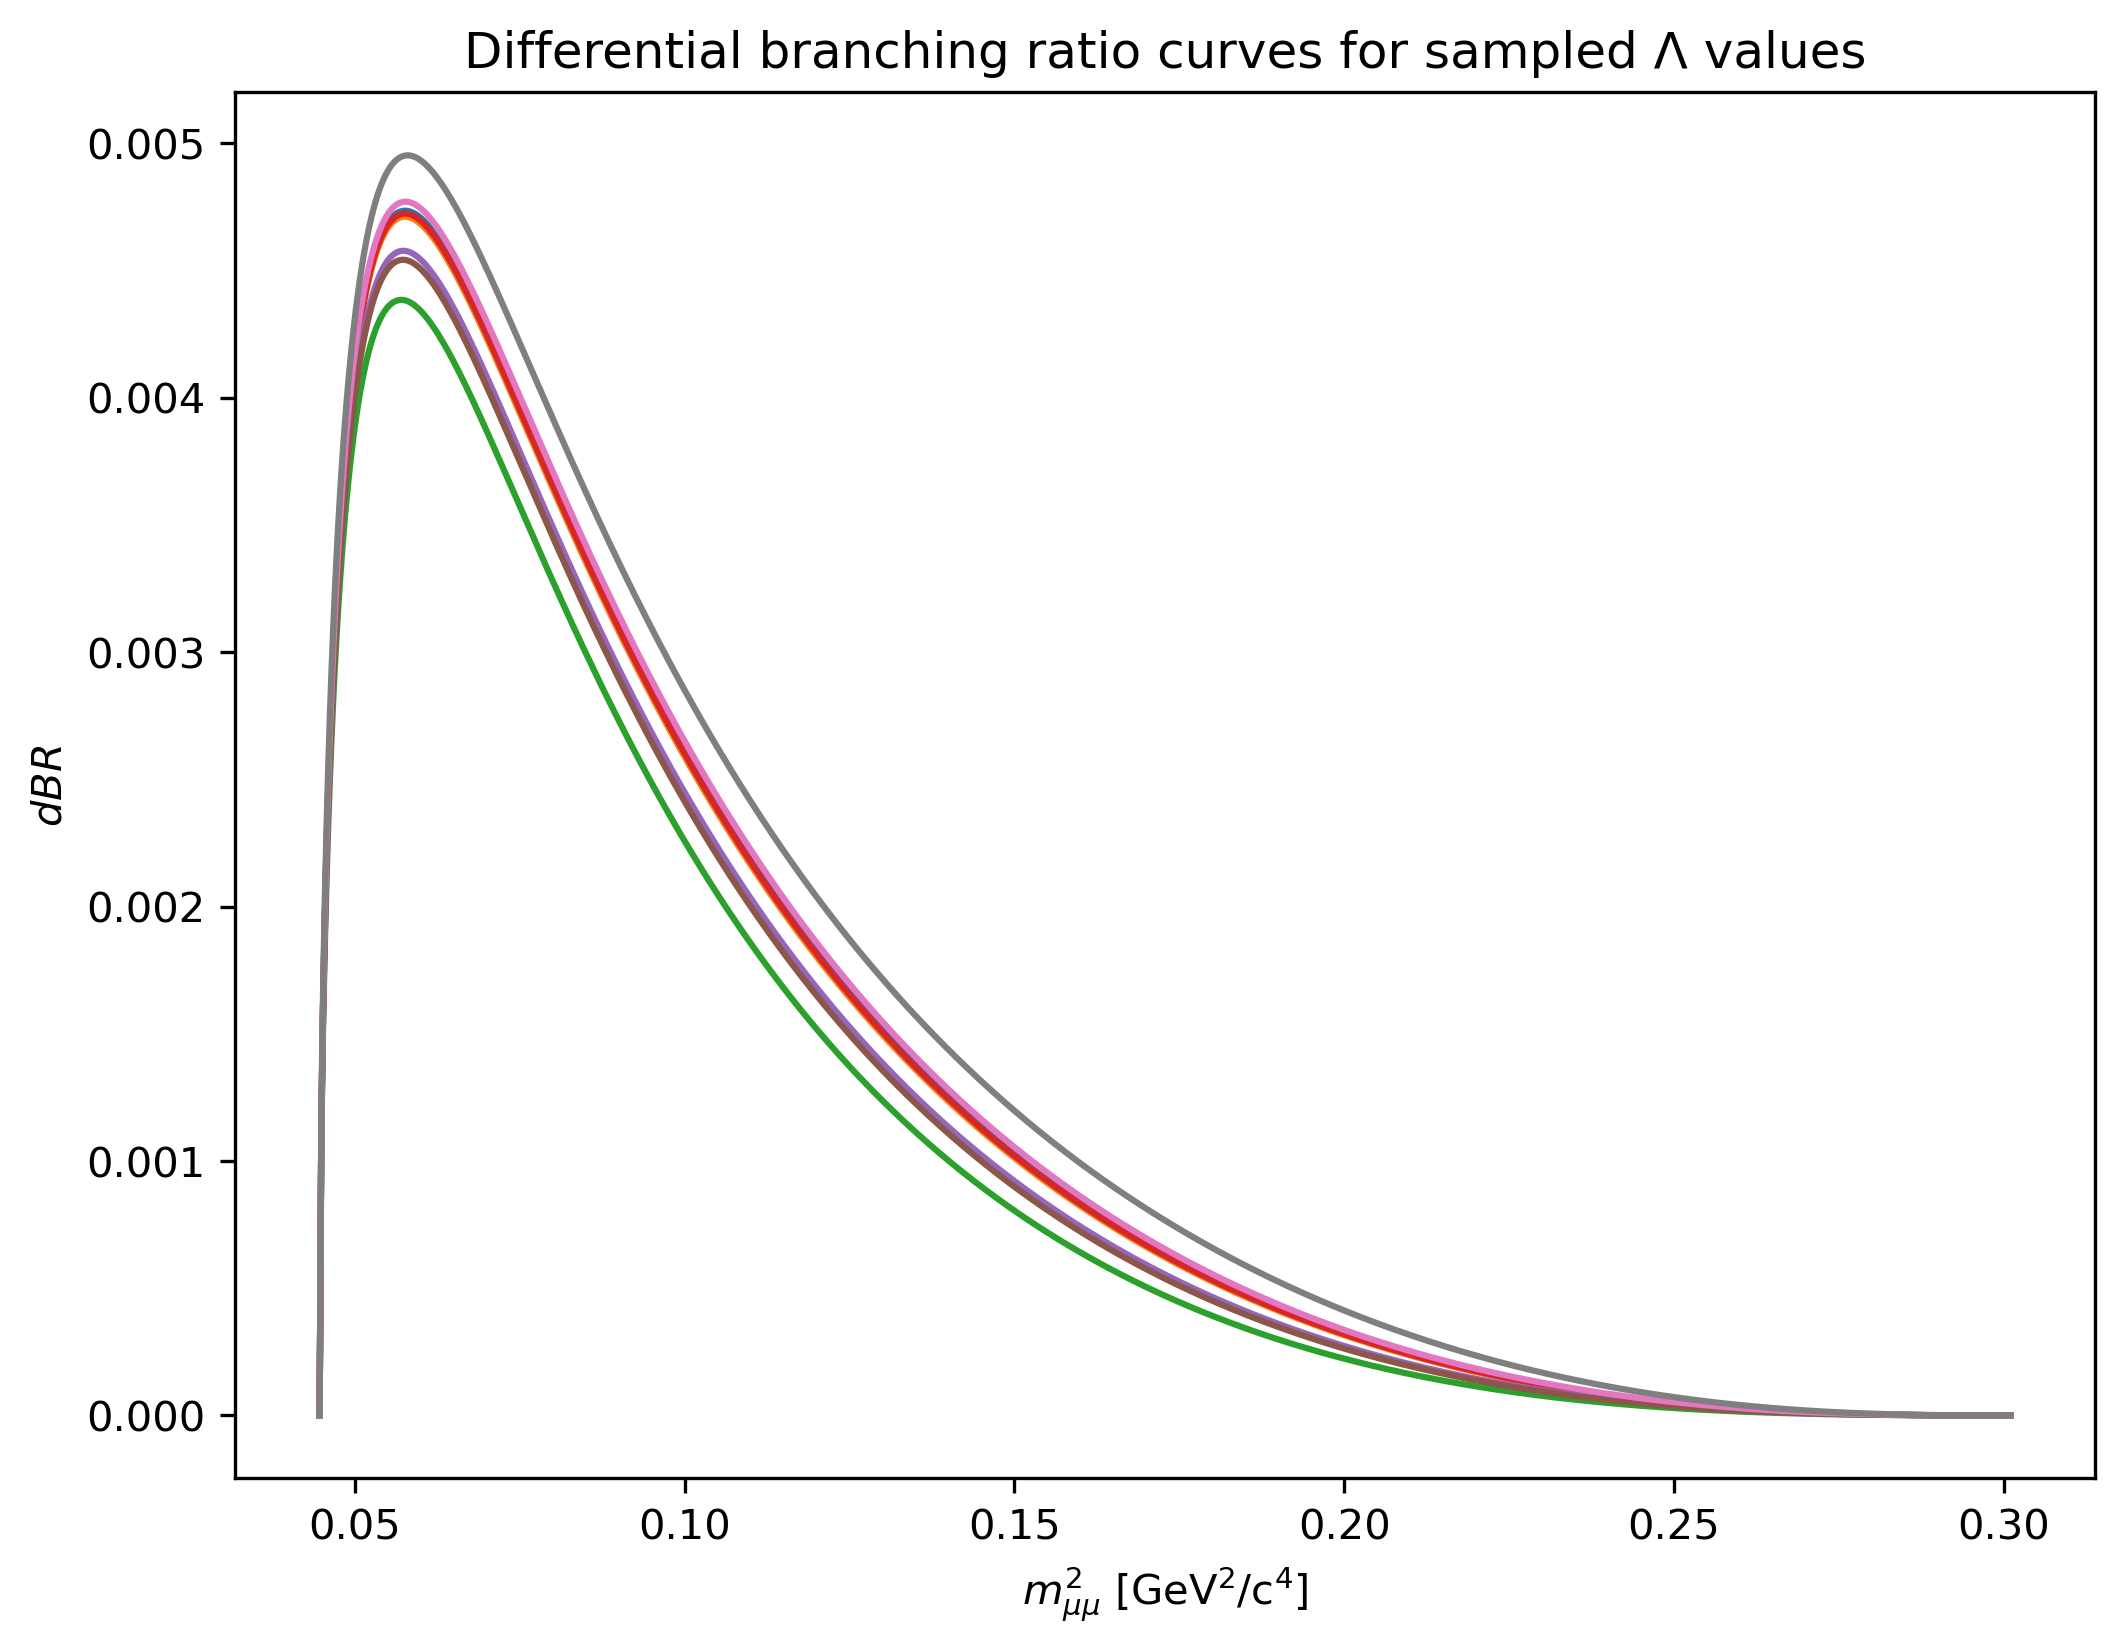

In [93]:
# Plot the distribution of branching ratio curves from the sampled Lambdas
# Do this for just 10 randomly sampled Lambdas to avoid overcrowding the plot.
plt.figure(figsize=(8, 6))
for Lambda in np.random.choice(Lambdas, size=10, replace=False):
    if Lambda**2 < ff.q2_max: continue
    q2s = np.linspace(ff.q2_min, ff.q2_max, 1000)
    dbr_values = ff.prefactor * np.array([ff.integrand(q2, Lambda) for q2 in q2s])
    plt.plot(q2s, dbr_values)

plt.xlabel(r"$m^2_{\mu\mu}$ [GeV$^2$/c$^4$]")
plt.ylabel(r"$dBR$")
plt.title("Differential branching ratio curves for sampled Λ values")
plt.show()

---

### Method II: $\pm\sigma$ Difference
Calculate branching ratio from $\Lambda+\sigma_\Lambda$ and $\Lambda-\sigma_\Lambda$, find the difference, then divide by 2. This method is quick and works well if the lambda uncertainty is smooth and approximately linear.

In [94]:
# Define Lambda values
Lambda_p = LAMBDA0[0] + LAMBDA0[1]
Lambda_m = LAMBDA0[0] - LAMBDA0[1]

ff_p = FormFactor(Lambda0=Lambda_p)
ff_m = FormFactor(Lambda0=Lambda_m)

br_p = ff_p.branching_ratio(Lambda_p)
br_m = ff_m.branching_ratio(Lambda_m)

# Print values
print(f"BR+ = {br_p * 10000.:.2f}e-4")
print(f"BR- = {br_m * 10000.:.2f}e-4\n")

# Find difference
dbr = abs((br_p - br_m)) / 2.
print(f"BR uncertainty = {dbr * 10000.:.2f}e-4\n")

BR+ = 2.96e-4
BR- = 3.83e-4

BR uncertainty = 0.43e-4



Phil also mentioned a slightly different method of doing this. I'll try it just to see if there's any difference.

In [95]:
# Define Lambda values
Lambda_p = LAMBDA0[0] + LAMBDA0[1]
Lambda_m = LAMBDA0[0] - LAMBDA0[1]

ff_p = FormFactor(Lambda0=Lambda_p)
ff_m = FormFactor(Lambda0=Lambda_m)
ff = FormFactor(Lambda0=LAMBDA0[0])

dbr_p = ff_p.branching_ratio(Lambda_p) - ff.branching_ratio(LAMBDA0[0])
dbr_m = ff.branching_ratio(LAMBDA0[0]) - ff_m.branching_ratio(Lambda_m)

# Print values
print(f"ΔBR+ = {dbr_p * 10000.:.2f}e-4")
print(f"ΔBR- = {dbr_m * 10000.:.2f}e-4")

# Find average
dbr = abs((dbr_p + dbr_m)) / 2.
print(f"BR uncertainty = {dbr * 10000.:.2f}e-4")

ΔBR+ = -0.30e-4
ΔBR- = -0.57e-4
BR uncertainty = 0.43e-4


The end result is the same.

ΔBR+ = -0.30e-4
ΔBR- = -0.57e-4
BR uncertainty = 0.43e-4


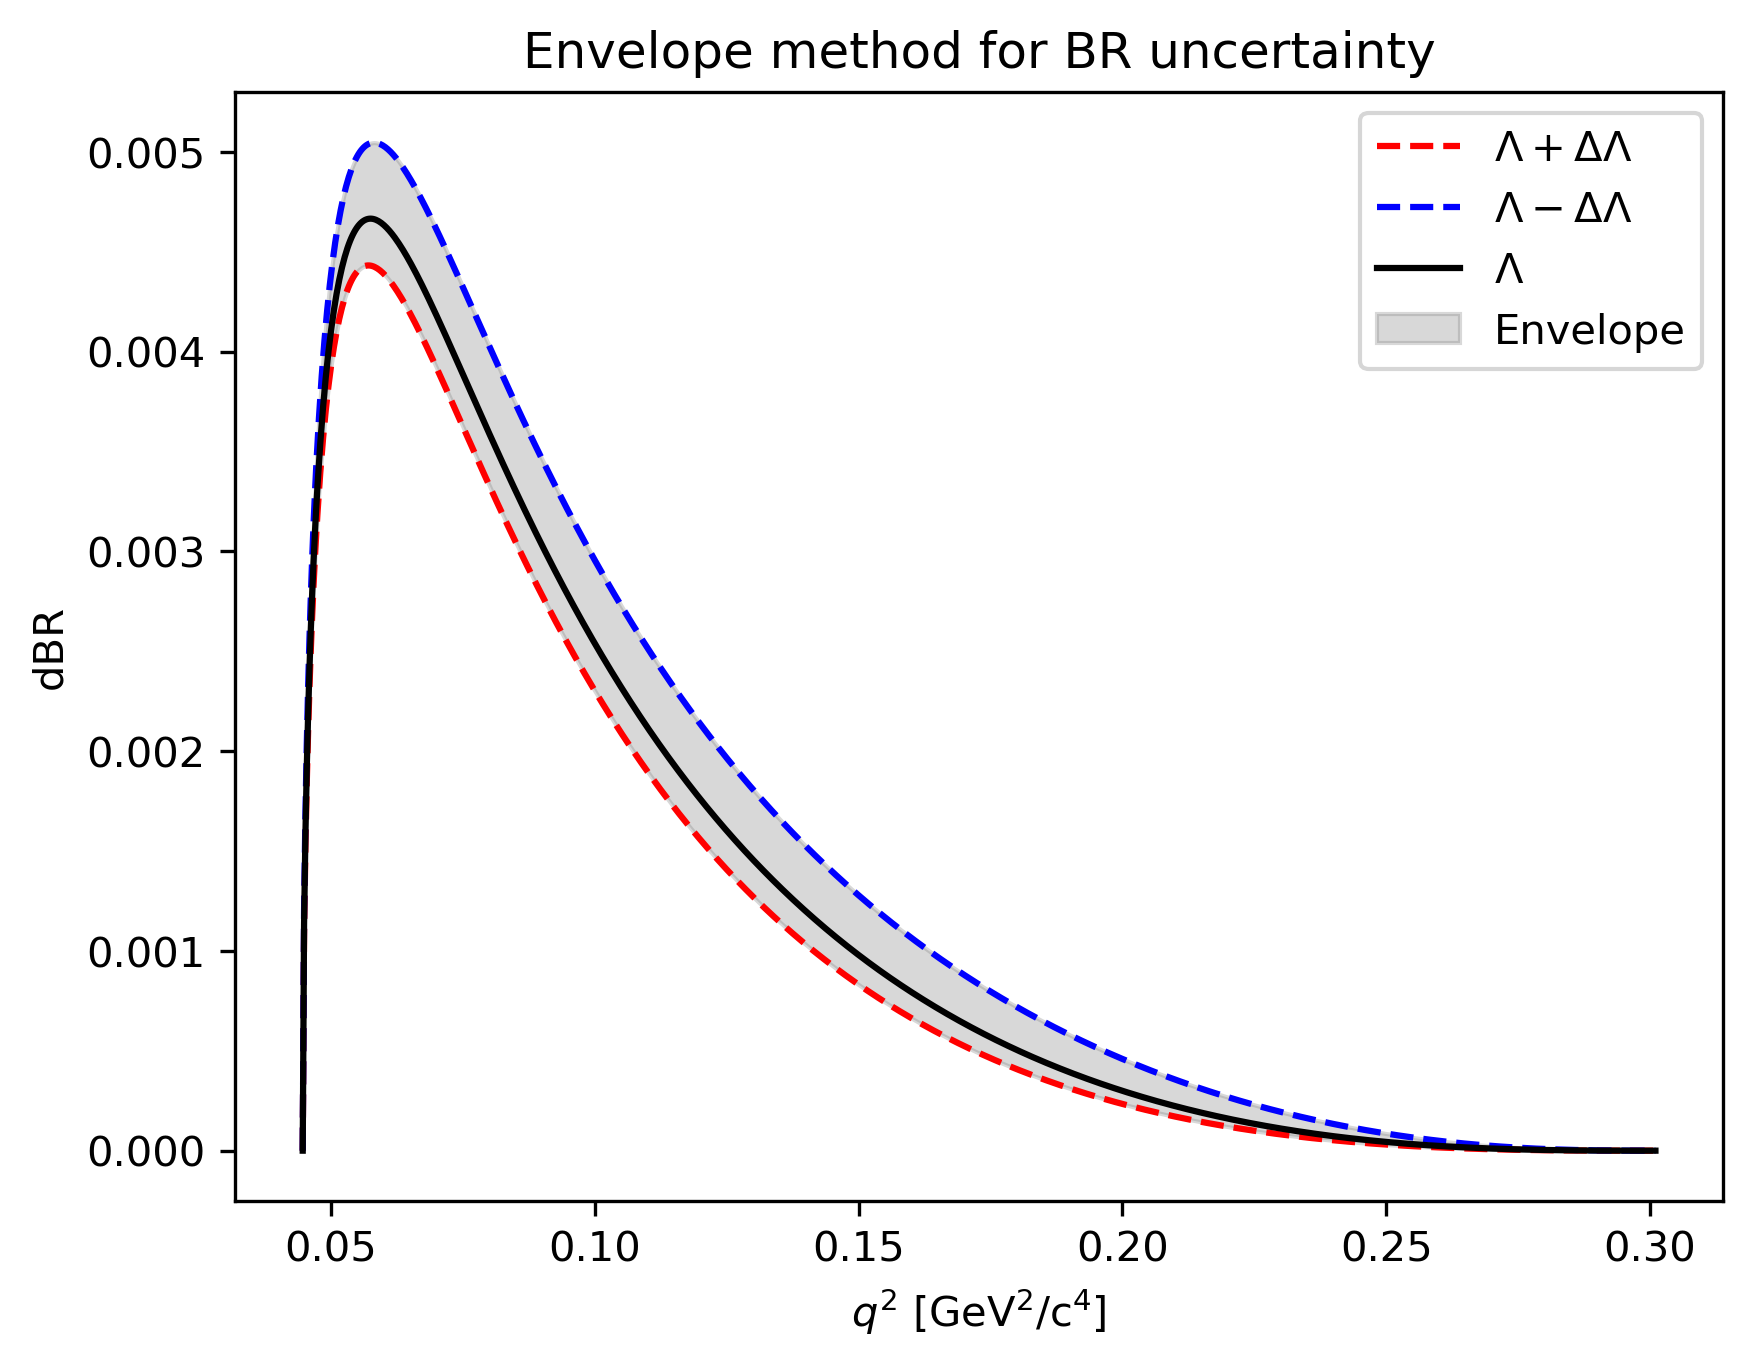

In [96]:
# Visualize envelope method
# Define Lambda values
Lambda_p = LAMBDA0[0] + LAMBDA0[1]
Lambda_m = LAMBDA0[0] - LAMBDA0[1]

# Calculate branching ratios for each Lambda value
ff_p = FormFactor(Lambda0=Lambda_p)
ff_m = FormFactor(Lambda0=Lambda_m)
ff = FormFactor(Lambda0=LAMBDA0[0])

# Find uncertainty using envelope method
dbr_p = ff_p.branching_ratio(Lambda_p) - ff.branching_ratio(LAMBDA0[0])
dbr_m = ff.branching_ratio(LAMBDA0[0]) - ff_m.branching_ratio(Lambda_m)
dbr = abs((dbr_p + dbr_m)) / 2.

# Print values
print(f"ΔBR+ = {dbr_p * 10000.:.2f}e-4")
print(f"ΔBR- = {dbr_m * 10000.:.2f}e-4")
print(f"BR uncertainty = {dbr * 10000.:.2f}e-4")


# Generate q^2 values and corresponding integrand values
q2s = np.linspace(ff.q2_min, ff.q2_max, 1000)
dbr_p_values = ff.prefactor * np.array([ff_p.integrand(q2, Lambda_p) for q2 in q2s])
dbr_m_values = ff.prefactor * np.array([ff_m.integrand(q2, Lambda_m) for q2 in q2s])
dbr_values = ff.prefactor * np.array([ff.integrand(q2, LAMBDA0[0]) for q2 in q2s])

# Visualize envelope method
plt.plot(q2s, dbr_p_values, label=r'$\Lambda + \Delta\Lambda$', color='red', linestyle='--')
plt.plot(q2s, dbr_m_values, label=r'$\Lambda - \Delta\Lambda$', color='blue', linestyle='--') 
plt.plot(q2s, dbr_values, label=r'$\Lambda$', color='black', linestyle='-')
plt.fill_between(q2s, dbr_p_values, dbr_m_values, color='gray', alpha=0.3, label='Envelope')
plt.xlabel(r'$q^2$ [GeV$^2$/c$^4$]')
plt.ylabel('dBR')
plt.title('Envelope method for BR uncertainty')
plt.legend()
plt.show()

## Reconstructing Paper

Best coord: (m_eta=0.540127, alpha=0.007324, chi2=4.96e-06)
BR at best: 3.0994e-04 (target 3.10e-04)
dBR at best: 3.9932e-05 (target 4e-05)


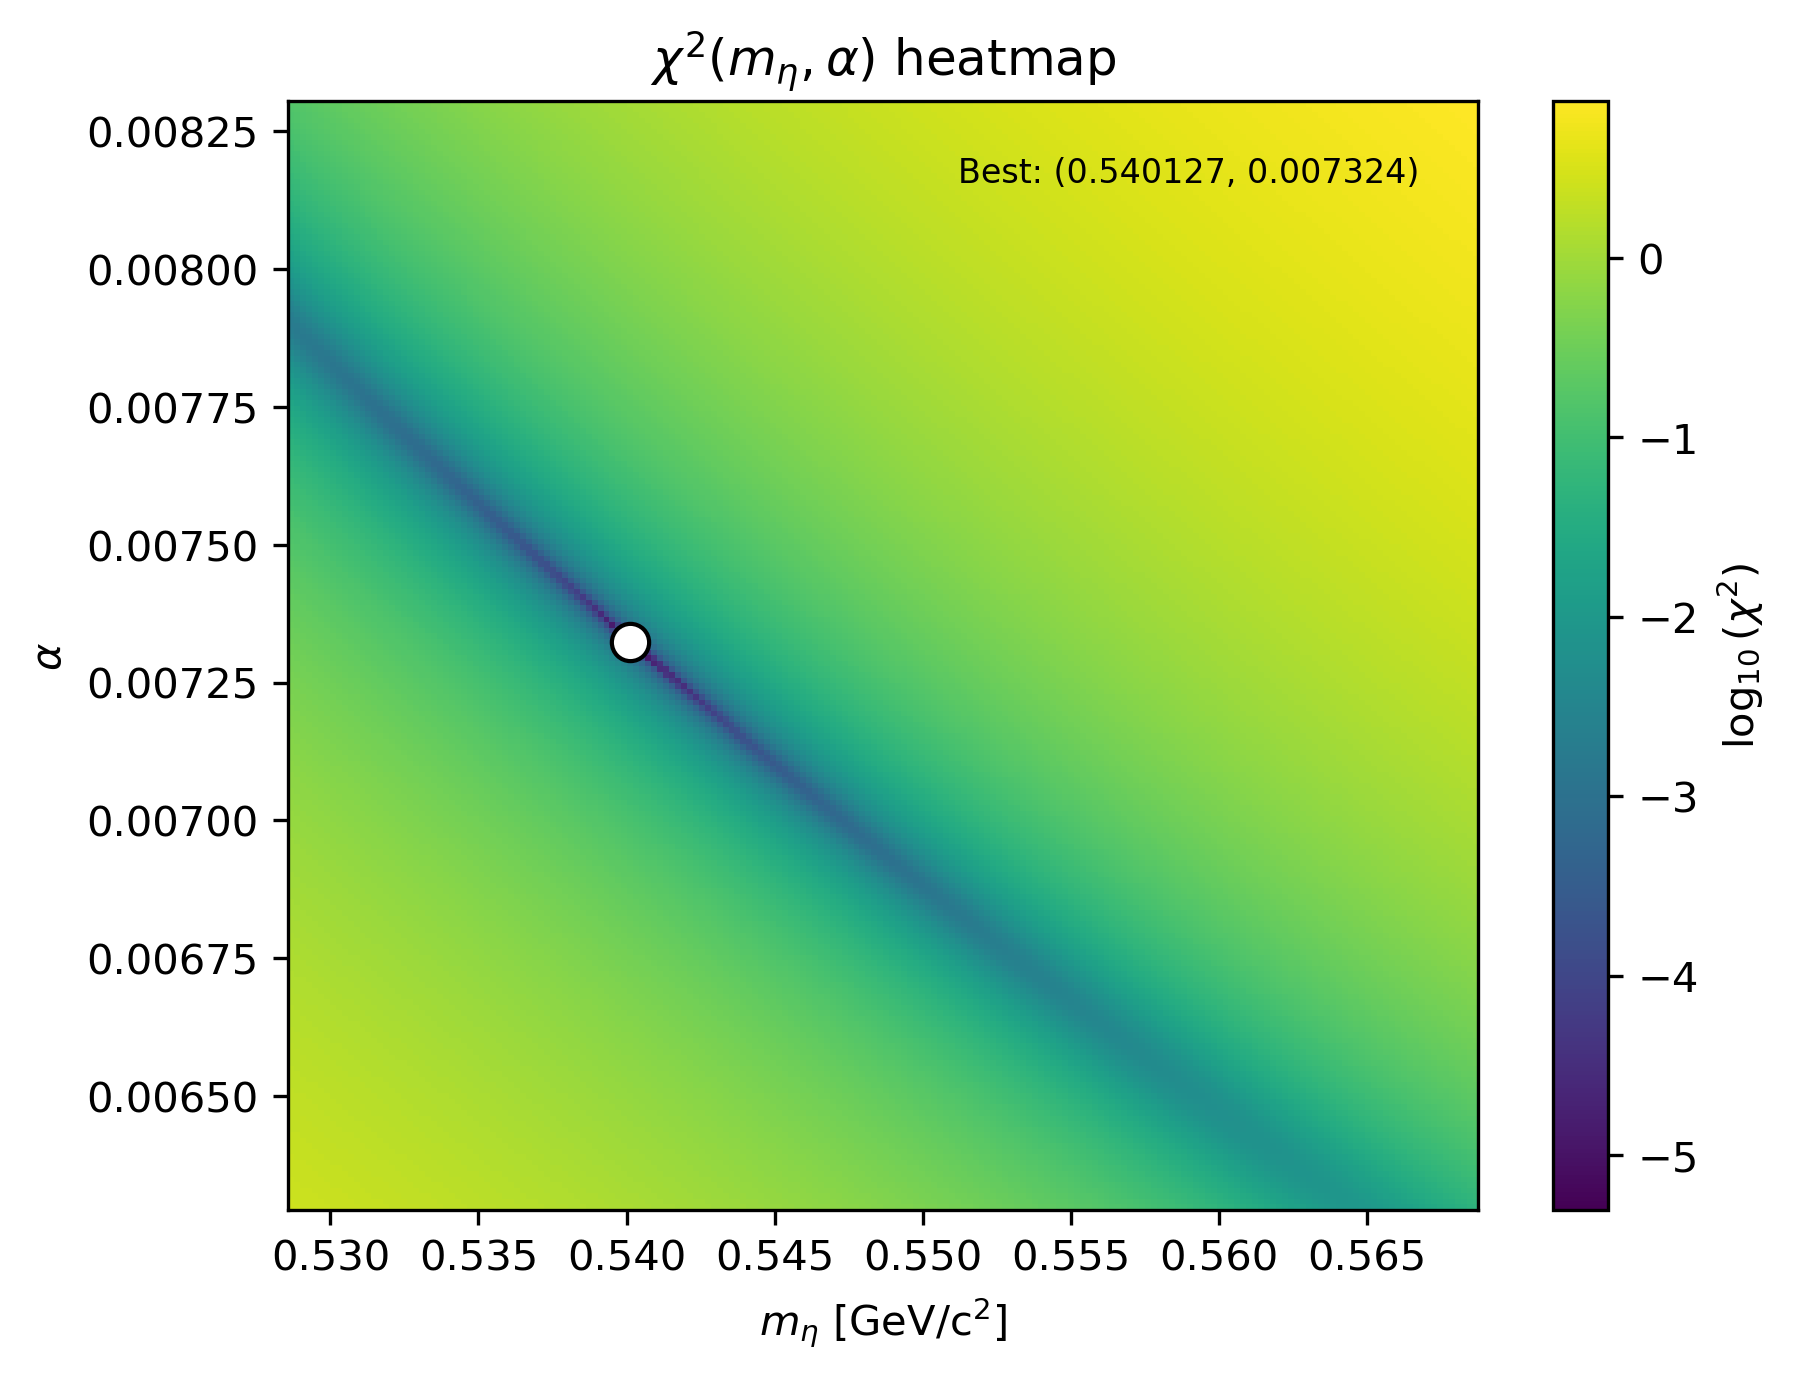

In [97]:
# Target values from paper
BR0, DBR0 = 3.1e-4, 0.4e-4

# Define Lambda values
Lambda0, dLambda0 = LAMBDA0
Lambda_p = Lambda0 + dLambda0
Lambda_m = Lambda0 - dLambda0

# Define eta mass range to search
# m_eta_vals = np.linspace(0.535, 0.555, 161)
# alpha_vals = np.linspace(0.0066, 0.0078, 161)
m_eta_vals = np.linspace(M_ETA-0.02, M_ETA+0.02, 200)
alpha_vals = np.linspace(ALPHA-0.001, ALPHA+0.001, 200)

# Compute BR and deltaBR over grid of m_eta and alpha values
# Create numpy arrays to hold results 
I_o = np.zeros(m_eta_vals.shape, dtype=float)
I_p = np.zeros(m_eta_vals.shape, dtype=float)
I_m = np.zeros(m_eta_vals.shape, dtype=float)

# Calculate integrals (use full q^2 range)
for i, m_eta in enumerate(m_eta_vals):
    ff = FormFactor(m_eta=m_eta)
    try:
        I_o[i], _ = ff.integrate(Lambda0)
        I_p[i], _ = ff.integrate(Lambda_p)
        I_m[i], _ = ff.integrate(Lambda_m)
    except Exception: continue

# Calculate prefactor values
prefactor_vals = (2.0 * alpha_vals) / (3.0 * np.pi) * BR_ETA2GG

# Calculate BR and dBR values
BR_vals = np.outer(prefactor_vals, I_o)
dBR_vals = np.outer(prefactor_vals, np.abs((I_p - I_m))) / 2.0

# Calculate chi2 values
chi2_vals = ((BR_vals - BR0) / DBR0)**2 + ((dBR_vals - DBR0) / DBR0)**2
# Find minimum chi2 value and corresponding m_eta and alpha
# To understand unravel_index(): numpy arrays are stored in a 1d format. argmin
# returns the minimum value's 1d index. unravel_index interprets what that value
# is in the original shape of the array.
best_idx = np.unravel_index(np.argmin(chi2_vals), chi2_vals.shape)
best_alpha = alpha_vals[best_idx[0]]
best_m_eta = m_eta_vals[best_idx[1]]
best_chi2 = chi2_vals[best_idx]

print(f'Best coord: (m_eta={best_m_eta:.6f}, alpha={best_alpha:.6f}, chi2={best_chi2:.2e})')
print(f'BR at best: {BR_vals[best_idx]:.4e} (target {BR0:.2e})')
print(f'dBR at best: {dBR_vals[best_idx]:.4e} (target {DBR0:.0e})')

# Plot chi2 as 2d heatmap
def plot_chi2(x, y, z, log_scale=True):
    """
    Helper function to plot data with associated colormap.
    """
    fig, ax = plt.subplots()
    
    if log_scale: z = np.log10(z)
    c = ax.pcolormesh(x, y, z, shading="auto")
    fig.colorbar(c, ax=ax, label=r'$\log_{10}(\chi^2)$')
    
    ax.scatter([best_m_eta], [best_alpha], c='white', edgecolors='black', s=80)
    ax.set_xlabel(r'$m_\eta$ [GeV/c$^2$]')
    ax.set_ylabel(r'$\alpha$')
    ax.set_title(r'$\chi^2(m_\eta, \alpha)$ heatmap')
    # Add label giving x,y value for best point in top right corner
    ax.text(0.95, 0.95, fr'Best: ({best_m_eta:.6f}, {best_alpha:.6f})',
            transform=ax.transAxes, fontsize=8, verticalalignment='top', 
            horizontalalignment='right')

    plt.show()

plot_chi2(m_eta_vals, alpha_vals, chi2_vals)

## Finding q2 max value

We want to compute the statistical uncertainty $1/\sqrt{N_{sig}(q^2_{max})}$, where $N_{sig}$ is the expected signal yield as a function of $q^2_{max}$.

The total uncertainty is:
$$\delta^2_{\rm tot}(q^2_{\rm max}) = \delta^2_F(q^2_{\rm max}) + \delta^2_{\rm data}(q^2_{\rm max}),$$
where $\delta_F = $ `dBR/BR` and $\delta_{\rm data} = 1/\sqrt{N(q^2_{\rm max})}$.

Minimising $\delta_{tot}$ over $q^2_{max}$ gives the optimal upper cut, which should look like a minimum (well) in the uncertainty plot.

In [98]:
# Define q2 max values to loop over
q2_max_values = np.arange((2 * M_MU) ** 2, 0.3, 0.001)

### $\delta_F$

Let's calculate $\delta_F$ and plot it first.

In [99]:
from scipy.integrate import cumulative_trapezoid

# Target values from paper
BR0, DBR0 = 3.1e-4, 0.4e-4

# Define Lambda values
Lambda0, dLambda0 = LAMBDA0
Lambda_p = Lambda0 + dLambda0
Lambda_m = Lambda0 - dLambda0

pairs = [[.54867, .00694],   # digitized from paper (alt alpha = 0.0074 from pdg)
         [.540127, .007324], # best fit from above
         ]
fit_vals = []

for pair in pairs:
    m_eta, alpha = pair
    ff_temp = FormFactor(m_eta=m_eta, alpha=alpha)
    prefactor = ff_temp.prefactor

    # Fine q^2 grid on which to evaluate the differential branching ratio
    q2_grid = np.linspace(ff_temp.q2_min, ff_temp.q2_max, 5000)

    # dBR/dq^2 at each Lambda value (these are the integrand * prefactor)
    dBR_dq2_o = prefactor * np.array([ff_temp.integrand(q2, Lambda0) for q2 in q2_grid])
    dBR_dq2_p = prefactor * np.array([ff_temp.integrand(q2, Lambda_p) for q2 in q2_grid])
    dBR_dq2_m = prefactor * np.array([ff_temp.integrand(q2, Lambda_m) for q2 in q2_grid])

    # Pointwise envelope of the differential BR (sign-preserving for now)
    delta_dBR_dq2 = (dBR_dq2_p - dBR_dq2_m) / 2.0

    # Cumulative integrals up to each q2 in the grid
    BR_cum  = cumulative_trapezoid(dBR_dq2_o, q2_grid, initial=0.0)
    dBR_cum = np.abs(cumulative_trapezoid(delta_dBR_dq2, q2_grid, initial=0.0))
    print(f"BR_cum[-1] = {BR_cum[-1]:.2e}, dBR_cum[-1] = {dBR_cum[-1]:.2e}")  # sanity check

    # Evaluate at the shared q2_max_values used by the other plots
    br_at  = np.interp(q2_max_values, q2_grid, BR_cum)
    unc_at = np.interp(q2_max_values, q2_grid, dBR_cum)

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(br_at > 0, unc_at / br_at, np.inf)

    fit_vals.append(np.column_stack([q2_max_values, ratio, br_at, unc_at]))

fit_vals_pdg = fit_vals[0]
fit_vals_best = fit_vals[1]


BR_cum[-1] = 3.10e-04, dBR_cum[-1] = 4.12e-05
BR_cum[-1] = 3.10e-04, dBR_cum[-1] = 3.99e-05


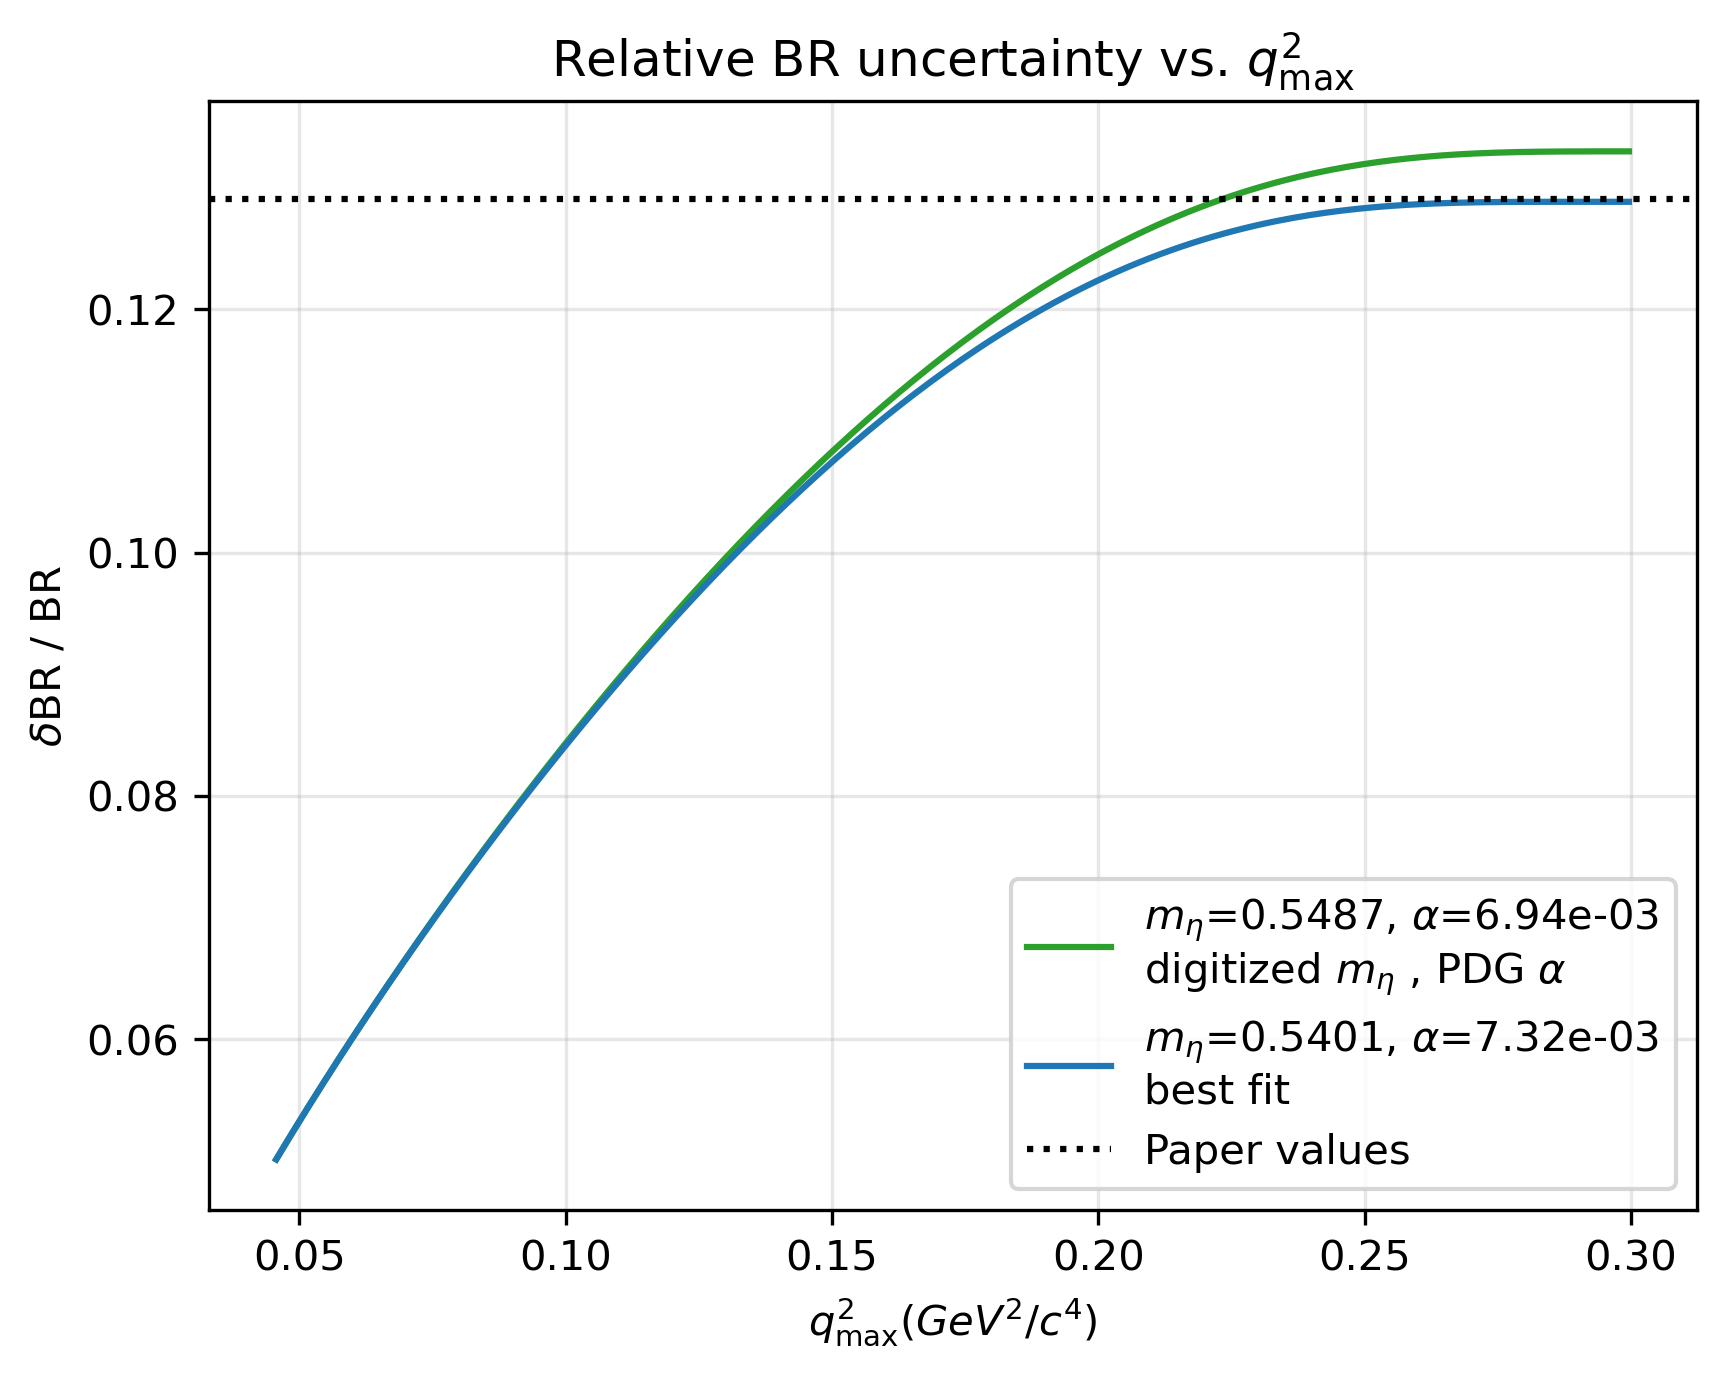

In [154]:
plt.plot(fit_vals_pdg[:,0], fit_vals_pdg[:,1], color='tab:green', label=fr"$m_\eta$={pairs[0][0]:.4f}, $\alpha$={pairs[0][1]:.2e}" + "\n" + r"digitized $m_\eta$ , PDG $\alpha$")
plt.plot(fit_vals_best[:,0], fit_vals_best[:,1], color='tab:blue', label=fr"$m_\eta$={pairs[1][0]:.4f}, $\alpha$={pairs[1][1]:.2e}" + "\nbest fit")
# Plot reference line from paper
plt.axhline(DBR0 / BR0, color='black', linestyle=':', label='Paper values')
# plt.axhline(3.7e-5 / 3.1e-4, color='red', linestyle='--', label='lower unc')
# plt.yscale('log')
plt.xlabel(r'$q^2_{\max} (GeV^2/c^4)$')
plt.ylabel(r'$\delta$BR / BR')
plt.title(r'Relative BR uncertainty vs. $q^2_{\max}$')
plt.grid(alpha=0.3)
plt.legend()
# plt.xscale('log')
plt.show()

### $\delta_{data}$

Now let's calculate the statistical uncertainty from data (N) and plot it.

In [125]:
sig_vals = []

# Comes from Collision 18 Run 2 Turbo data with leptons stream (.mdst).
N_SIG = 140478
print(f'N_SIG = {N_SIG:.2f}')

# Get q2 histogram values from signal MC
import json
# N_sig changes with q2 max according to @q2_histogram.json values, which come
# from signal MC. 
with open('q2_histogram.json', 'r') as f:
    q2_histogram = json.load(f)
    bin_edges = np.asarray(q2_histogram["bin_edges"], dtype=float)
    counts = np.asarray(q2_histogram["counts"], dtype=float)
    # Treat N_sig count as N_SIG * cumulative fraction of events with q2 < q2 max
    total = counts.sum()

# Compare the min values, should be consistent
print(f'bin_edges min : {bin_edges[0]:.3f}')
print(f'(2 * M_MU) ** 2 : {(2 * M_MU) ** 2}')

# Compare the max values, should be consistent
print(f'bin_edges max : {bin_edges[-1]:.3f}')
print(f'M_ETA ** 2 : {M_ETA ** 2:.3f}')

# Define m_eta and alpha
pairs = [[.54867, .00694],  # digitized from paper (alt alpha = 0.0074 from pdg)
         [.540127, .007324],  # best fit from above
         ]
m_eta, alpha = pairs[1]  # best fit values  

# Sample over q2 max values
for q2_max in q2_max_values:
    # Find N_sig for each q2 max value
    n_sig = N_SIG * counts[bin_edges[:-1] < q2_max].sum() / total

    # Relative statistical uncertainty on the signal yield N_sig: 1/sqrt(N_sig)
    rel_stat_unc = 1 / math.sqrt(n_sig) if n_sig > 0 else np.inf

    # Append values to list
    sig_vals.append((q2_max, n_sig, rel_stat_unc))

sig_vals = np.asarray(sig_vals, dtype=float)
q2_sig = sig_vals[:, 0]
n_sig_rel_stat_unc = sig_vals[:, 2]


N_SIG = 140478.00
bin_edges min : 0.040
(2 * M_MU) ** 2 : 0.044654768407929
bin_edges max : 0.300
M_ETA ** 2 : 0.301


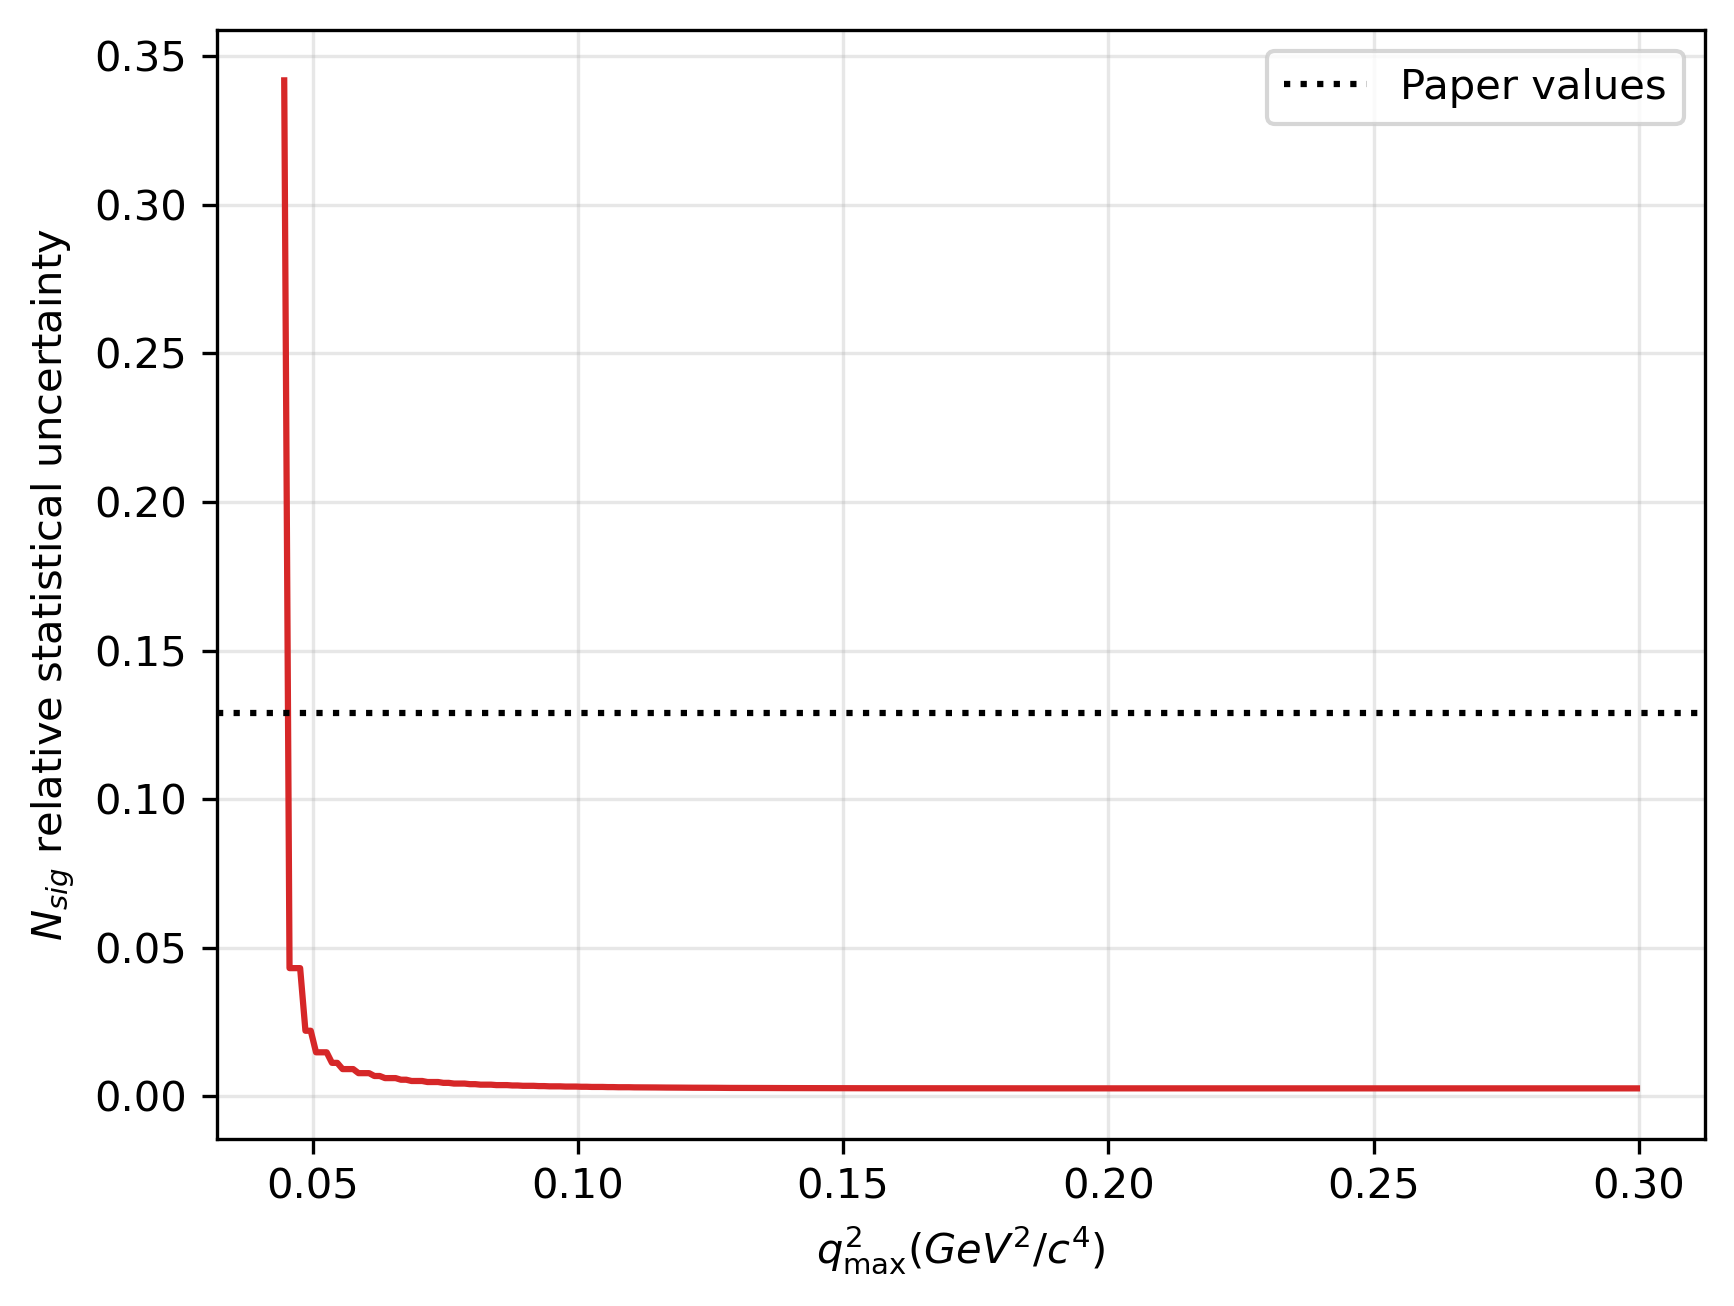

In [155]:
plt.plot(q2_sig, n_sig_rel_stat_unc, color='tab:red')
# Plot reference line from paper
plt.axhline(DBR0 / BR0, color='black', linestyle=':', label='Paper values')
# plt.axhline(3.7e-5 / 3.1e-4, color='red', linestyle='--', label='lower unc')
# plt.yscale('log')
plt.xlabel(r'$q^2_{\max} (GeV^2/c^4)$')
plt.ylabel(r'$N_{sig}$ relative statistical uncertainty')
# plt.title(r'$N_{sig}$ relative statistical uncertainty vs $q^2_{\max}$')
plt.grid(alpha=0.3)
plt.legend()
# plt.xscale('log')
plt.show()


### Total uncertainty

Now combine the uncertainty of the two values (in quadrature) and find minimum value.

Minimum: (0.051, 5.570e-02)


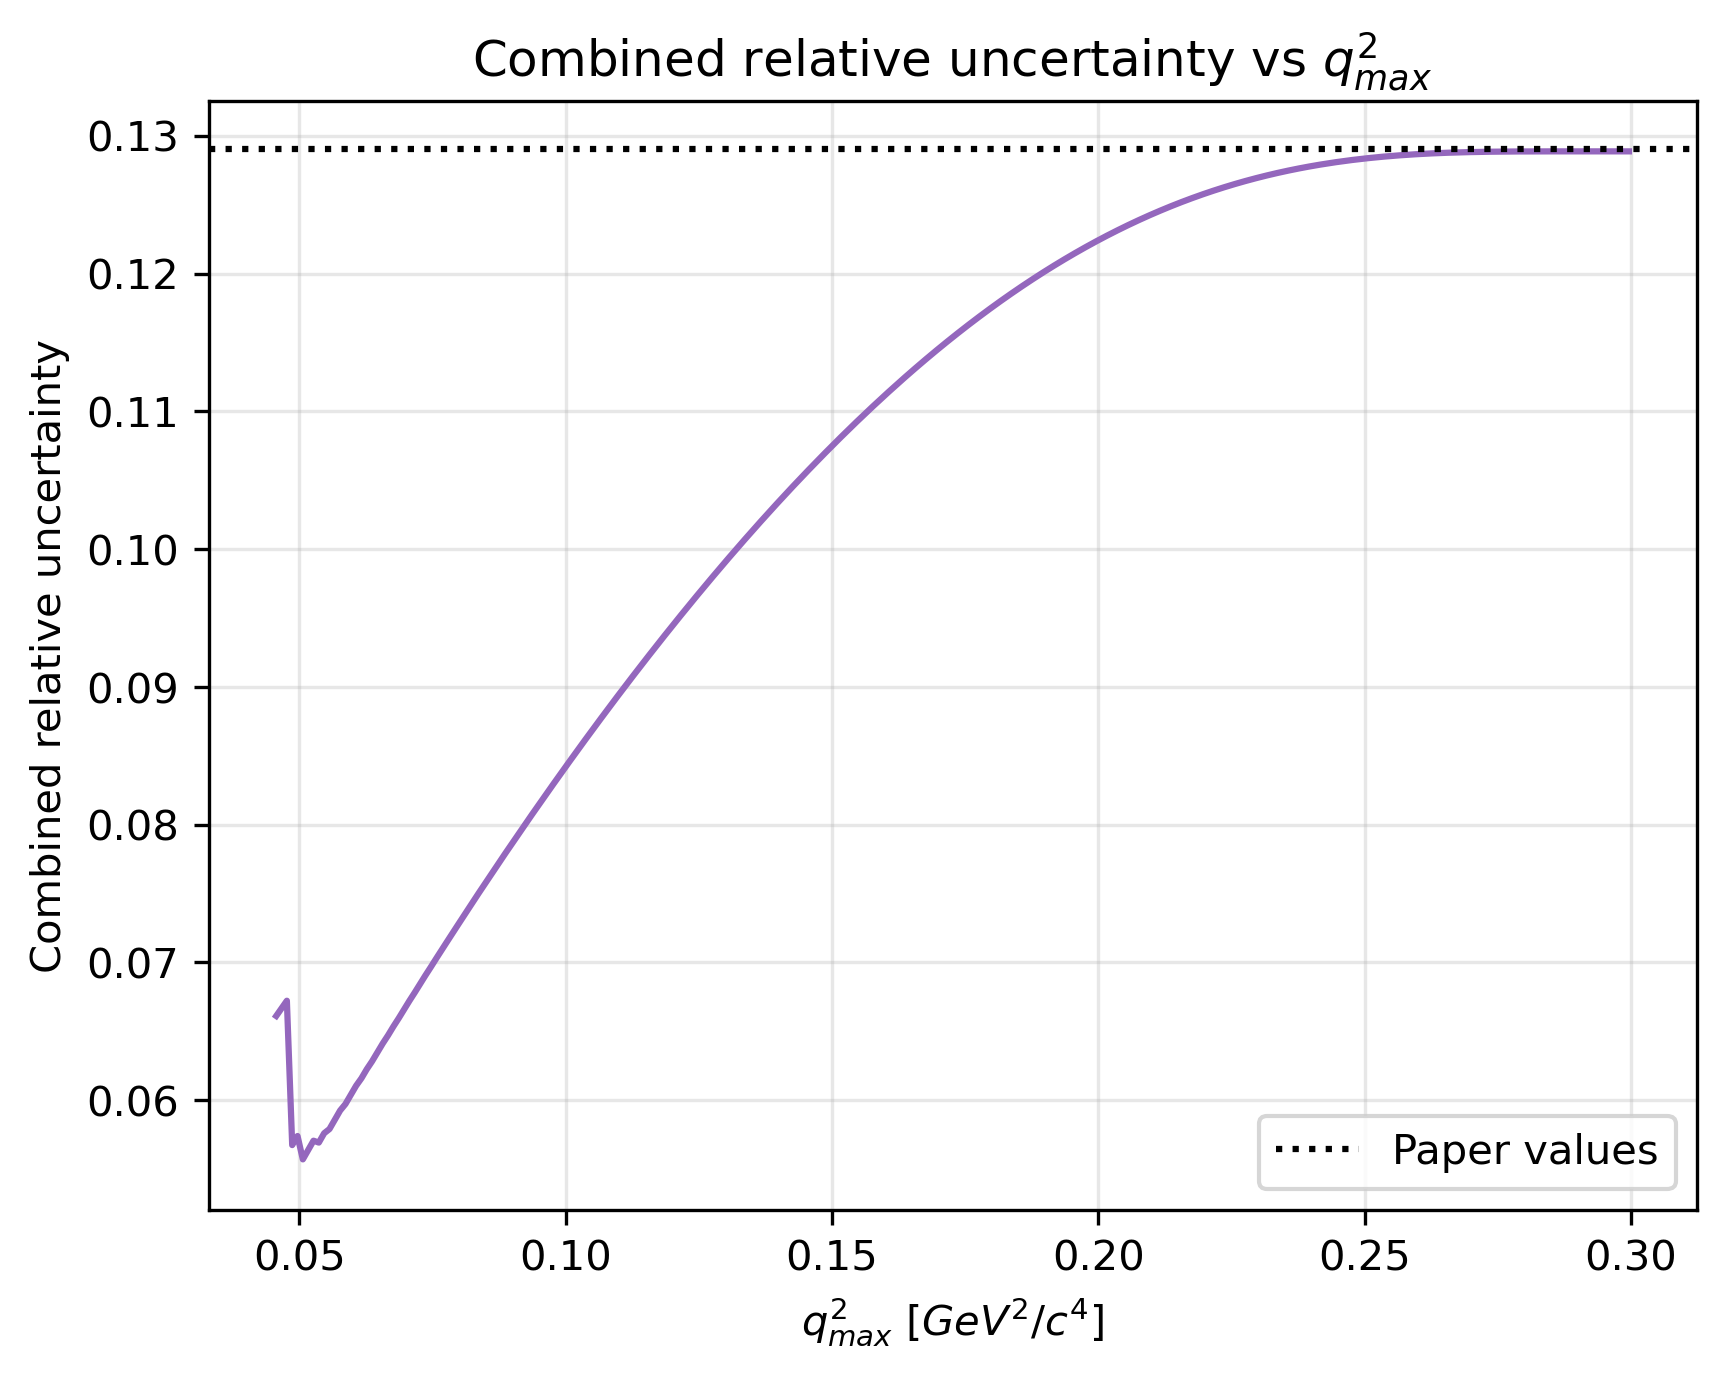

In [142]:
# delta_F (fit/theory) and delta_data (statistical) come from independent
# sources, so combine them in quadrature per the formula above.
delta_F = fit_vals_best[:, 1]
total_unc = np.sqrt(delta_F**2 + n_sig_rel_stat_unc**2)

# Test shapes and starting values for consistency
# print(f'q2_max_values.shape = {q2_max_values.shape}')
# print(f'total_unc.shape = {total_unc.shape}')
# print(f'q2 max -- min: {q2_max_values[0]:.3f}, max: {q2_max_values[-1]:.3f}')
# print(f'q2 fit -- min: {fit_vals_best[:,0][0]:.3f}, max: {fit_vals_best[:,0][-1]:.3f}')
# print(f'q2 sig -- min: {q2_sig[0]:.3f}, max: {q2_sig[-1]:.3f}')

# Find minimum total uncertainty and corresponding q2 max value
print(f'Minimum: ({q2_max_values[total_unc.argmin()]:.3f}, {total_unc.min():.3e})')

plt.plot(q2_max_values, total_unc, color='tab:purple')
plt.axhline(DBR0 / BR0, color='black', linestyle=':', label='Paper values')
plt.xlabel(r'$q^2_{max}$ [$GeV^2/c^4$]')
plt.ylabel(r'Combined relative uncertainty')
plt.title(r'Combined relative uncertainty vs $q^2_{max}$')
plt.grid(alpha=0.3)
plt.legend()
# plt.yscale('log')
plt.show()

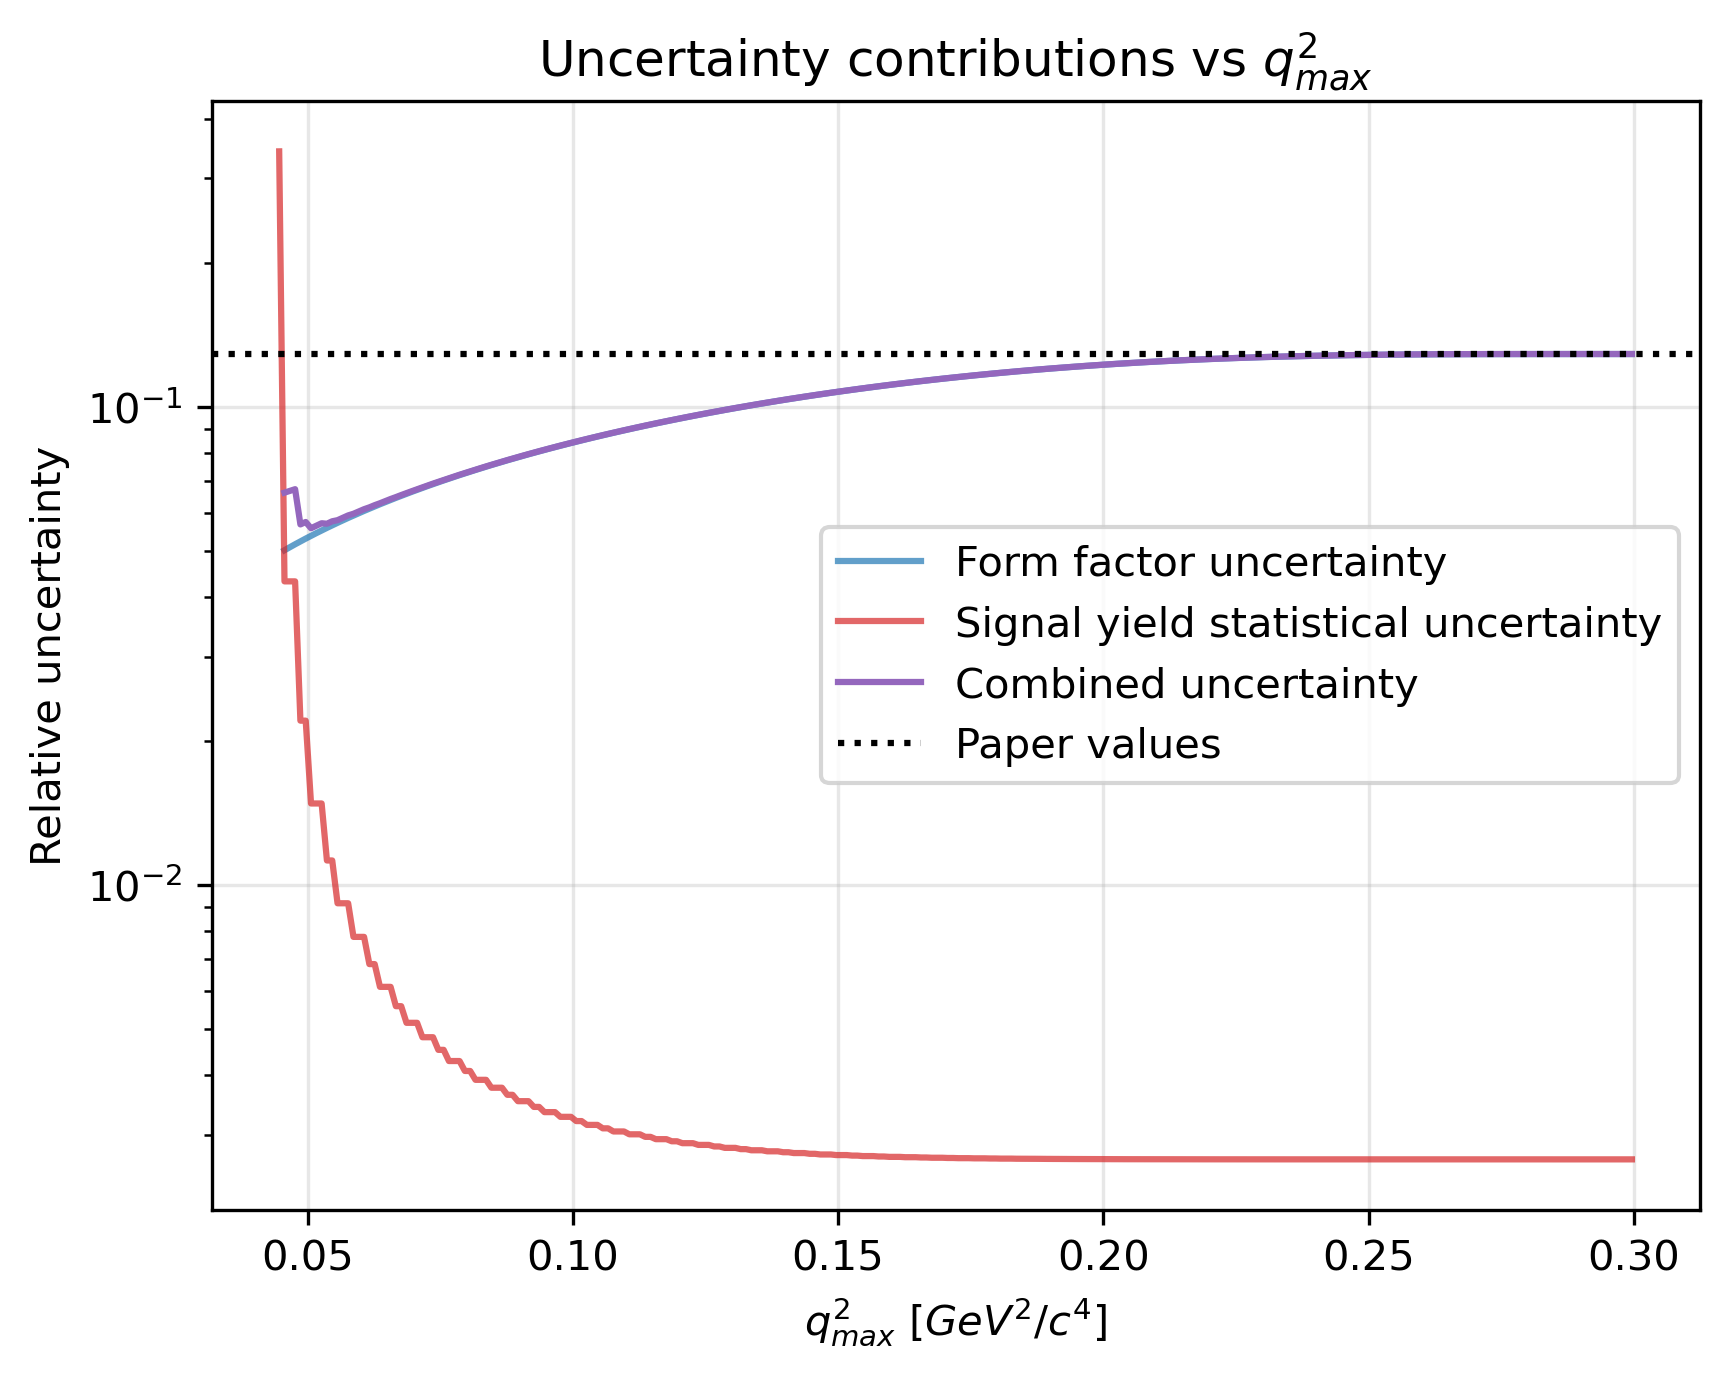

In [139]:
# Plot all three curves together for comparison
plt.plot(q2_max_values, fit_vals_best[:, 1], color='tab:blue', alpha=0.7, label='Form factor uncertainty')
plt.plot(q2_sig, n_sig_rel_stat_unc, color='tab:red', alpha=0.7, label='Signal yield statistical uncertainty')
plt.plot(q2_max_values, total_unc, color='tab:purple', label='Combined uncertainty')
plt.axhline(DBR0 / BR0, color='black', linestyle=':', label='Paper values')
plt.xlabel(r'$q^2_{max}$ [$GeV^2/c^4$]')
plt.ylabel(r'Relative uncertainty')
plt.title(r'Uncertainty contributions vs $q^2_{max}$')
plt.grid(alpha=0.3)
plt.legend()
plt.yscale('log')
plt.show()

Minimum: (0.053, 5.723e-02)


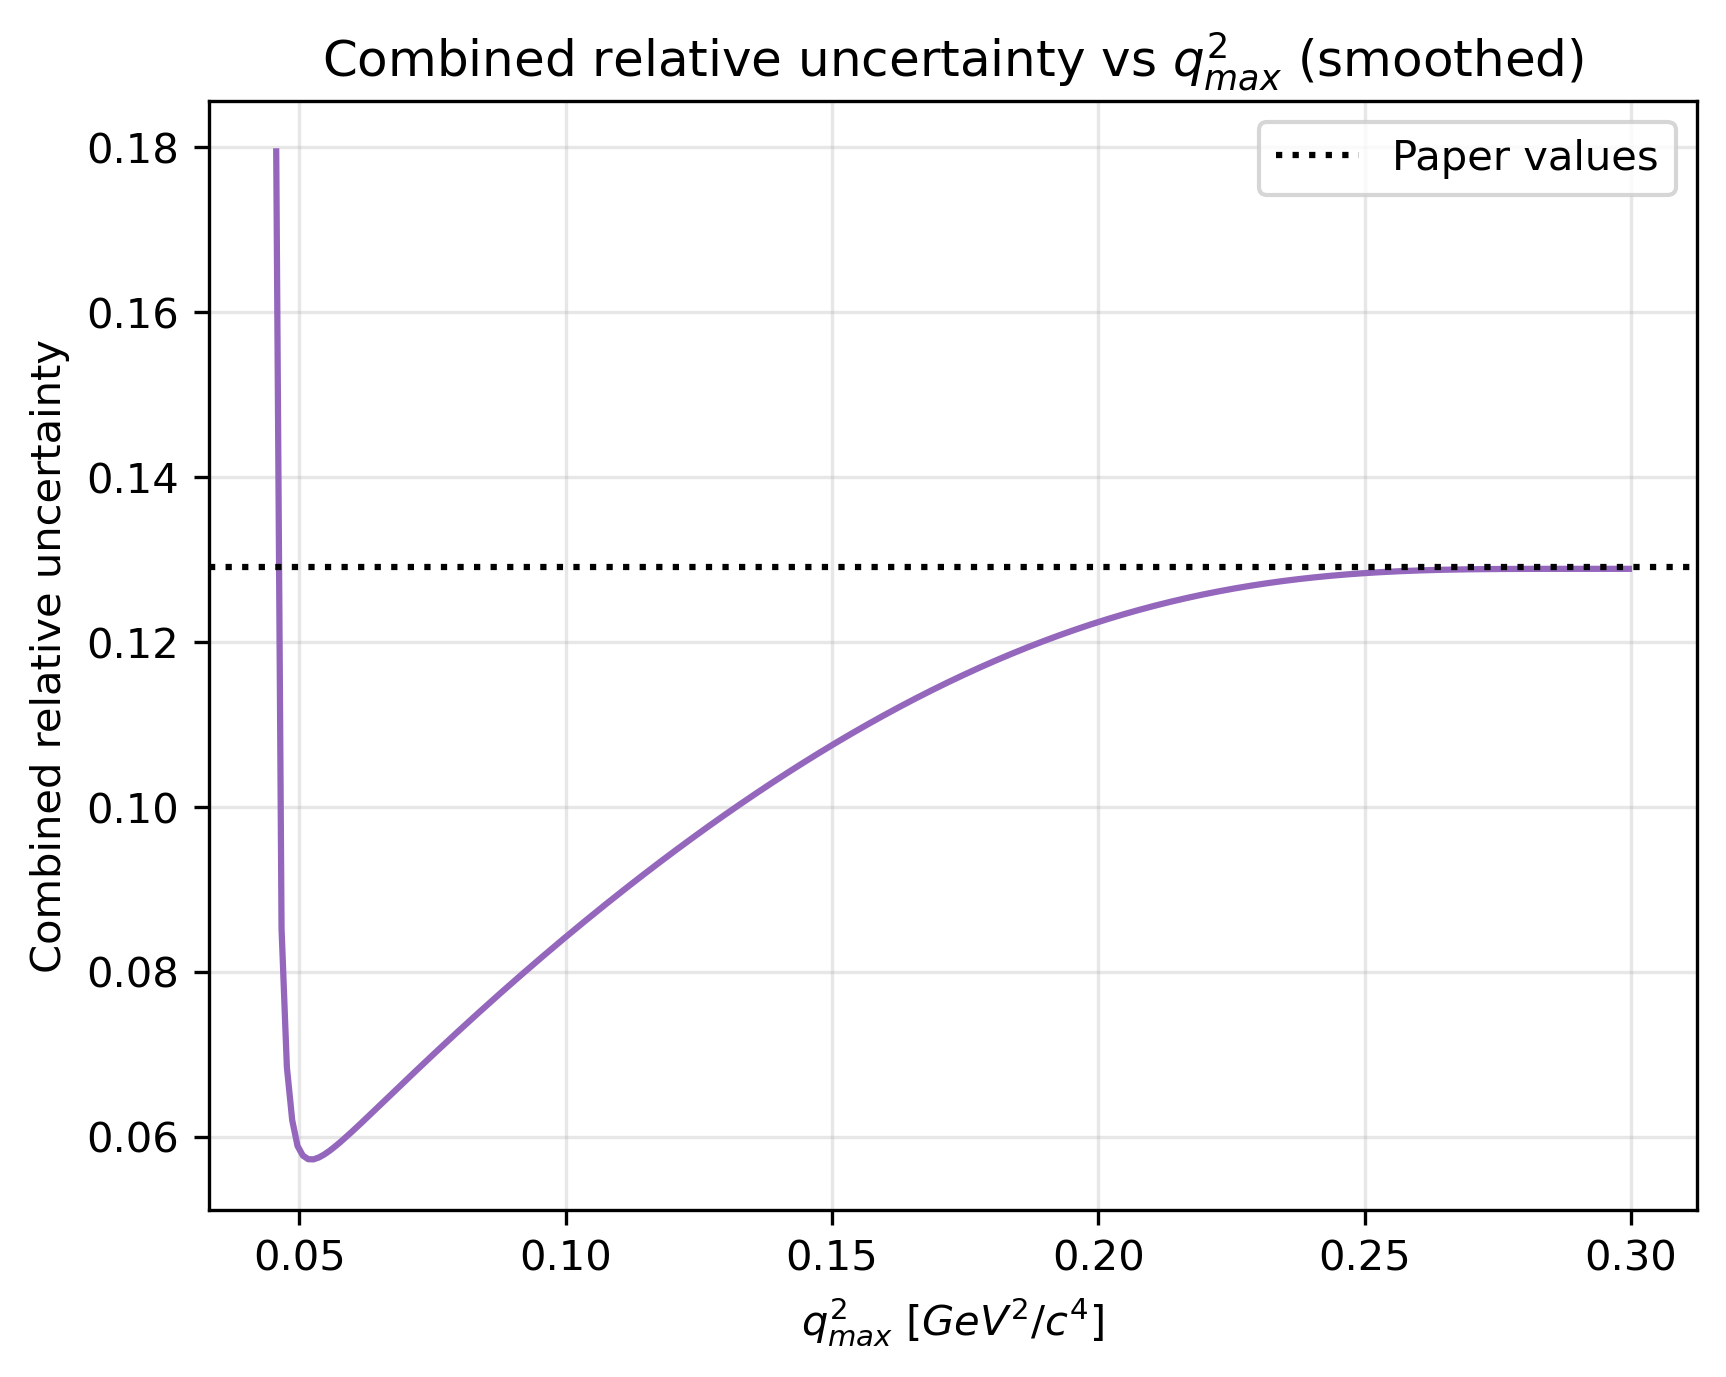

In [151]:
from scipy.interpolate import PchipInterpolator

# n_sig_rel_stat_unc is piecewise-constant because it is built from a
# histogrammed CDF. Build a smoothed version by interpolating the cumulative-
# count CDF with a monotonic cubic (PCHIP), then re-derive 1/sqrt(N_sig).
cdf_x = bin_edges
cdf_y = np.concatenate(([0.0], np.cumsum(counts) / total))
cdf_smooth = PchipInterpolator(cdf_x, cdf_y, extrapolate=False)

n_sig_smooth = N_SIG * cdf_smooth(q2_max_values)
n_sig_rel_stat_unc_smooth = np.where(n_sig_smooth > 0, 1.0 / np.sqrt(n_sig_smooth), np.inf)

# delta_F (fit/theory) and delta_data (statistical) come from independent
# sources, so combine them in quadrature per the formula above.
delta_F = fit_vals_best[:, 1]
total_unc_smooth = np.sqrt(delta_F**2 + n_sig_rel_stat_unc_smooth**2)

print(f'Minimum: ({q2_max_values[total_unc_smooth.argmin()]:.3f}, {total_unc_smooth.min():.3e})')

plt.plot(q2_max_values, total_unc_smooth, color='tab:purple')
# Plot reference line from paper
plt.axhline(DBR0 / BR0, color='black', linestyle=':', label='Paper values')
plt.xlabel(r'$q^2_{max}$ [$GeV^2/c^4$]')
plt.ylabel(r'Combined relative uncertainty')
plt.title(r'Combined relative uncertainty vs $q^2_{max}$ (smoothed)')
plt.grid(alpha=0.3)
plt.legend()
# plt.yscale('log')
plt.show()


---

## Extra Cells

The $\chi^2$ fit above makes these next cells less important, but it's still an 
interesting study of what mass and alpha values would be needed based on the 
apparent/assumed values from the paper. The results are puzzling, and in any 
case demonstrates that they probably should have stated these values to make 
their branching ratio calculation verifiable.

### Deriving mass of eta used in paper
Find the mass value needed to get a branching ratio of 3.1e-4 for fixed alpha = .0074.

|    Λ |   ΔΛ |   m_eta |      BR |
|------|------|---------|---------|
| 0.72 | 0.09 |  0.5407 | 0.00031 |


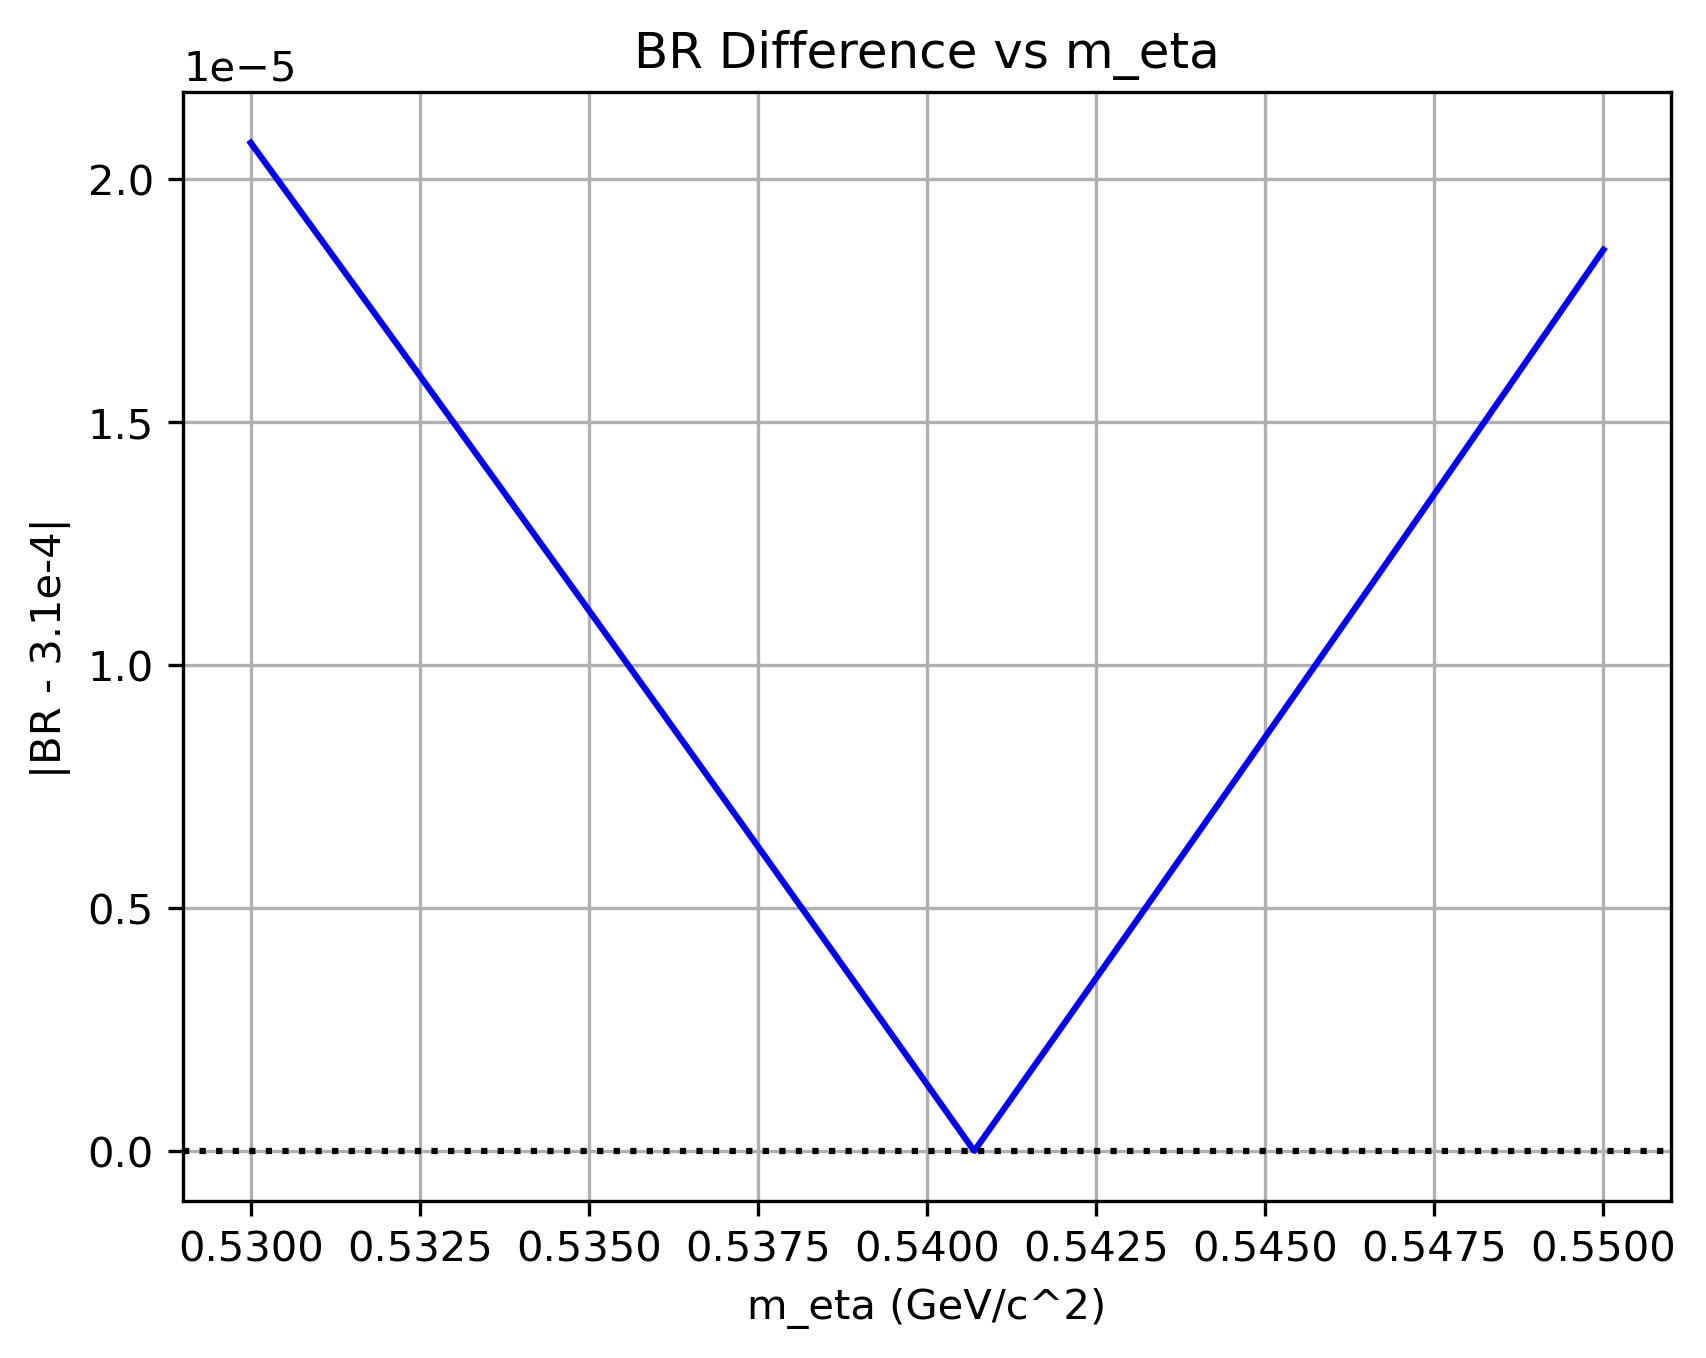

In [ ]:
br_target = 3.1e-4
table, values = [], []

for m_eta in np.arange(.53, .55, .00001):
    ff_temp = FormFactor(m_eta=m_eta)
    br_temp = ff_temp.branching_ratio(LAMBDA0[0])
    diff = abs(br_temp - br_target)
    values.append((m_eta, br_temp, diff))

# Find minimum
values = np.array(values)
# : = all rows; 2 = third column (diff)
min_idx = np.argmin(values[:,2])
# min_idx = row, 0 = first column (m_eta)
m_eta_best = values[min_idx,0]
# 1 = second column (br)
br_best = values[min_idx,1]

table.append([LAMBDA0[0], LAMBDA0[1], f"{m_eta_best:.6f}", f"{br_best * 1e4:.2f}e-4"])
# Print table
headers = ['Λ', 'ΔΛ', 'm_eta', 'BR']
print(tabulate(table, headers, tablefmt="github"))

# Plot
plt.plot(values[:,0], values[:,2], color='blue', linestyle='-')
plt.axhline(0, color='black', linestyle=':')
plt.xlabel('m_eta (GeV/c^2)')
plt.ylabel('|BR - 3.1e-4|')
plt.title('BR Difference vs m_eta')
plt.grid()
plt.show()


### Deriving alpha used in paper
Finds the alpha value needed to get exactly a branching ratio of 3.1e-4 for fixed m_eta = .54867.

In [106]:
ff = FormFactor(m_eta=M_ETA)
table = []

int_val, int_err = ff.integrate(LAMBDA0[0])
pre = BR0 / int_val
# Extract alpha from prefactor
alpha = (pre / 2) * (3 * np.pi) / BR_ETA2GG

# Print alpha based on m_eta from paper
print(f"m_eta = {M_ETA:.5f}, alpha = {alpha:.5f}")


m_eta = 0.54867, alpha = 0.00694


In [107]:
ff = FormFactor()
br0 = 3.1e-4  # target branching ratio
table = []

for fit in fits:
      int_val, int_err = ff.integrate(fit['Lambda'])
      pre = br0 / int_val
      # Extract alpha from prefactor
      alpha = (pre / 2) * (3 * np.pi) / BR_ETA2GG
      # Add to table
      table.append([fit['fit_Lambda'], fit['fit_K'], f"{alpha:.5f}"])

headers=['fit Λ', 'fit K', 'alpha']
print(tabulate(table, headers, tablefmt="github", colalign=(",","center","center")))


|   fit Λ |  fit K  |  alpha  |
|---------|---------|---------|
| True    |  True   | 0.00674 |
| True    |  False  | 0.00692 |
| False   |  True   | 0.00694 |
| False   |  False  | 0.00694 |


In [108]:
# Repeat using m_eta derived above (.53855), just to confirm alpha values
ff = FormFactor(m_eta=m_eta_best)
br0 = 3.1e-4  # target branching ratio
table = []

for fit in fits:
      int_val, int_err = ff.integrate(fit['Lambda'])
      pre = br0 / int_val
      # Extract alpha from prefactor
      alpha = (pre / 2) * (3 * np.pi) / BR_ETA2GG
      # Add to table
      table.append([fit['fit_Lambda'], fit['fit_K'], f"{alpha:.5f}"])

headers=['fit Λ', 'fit K', 'alpha']
print(tabulate(table, headers, tablefmt="github", colalign=(",","center","center")))

|   fit Λ |  fit K  |  alpha  |
|---------|---------|---------|
| True    |  True   | 0.00709 |
| True    |  False  | 0.00728 |
| False   |  True   | 0.0073  |
| False   |  False  | 0.0073  |


mu mu e e

In [109]:
# Alternate way to calculate dbr / br

# Target values from paper
BR0, DBR0 = 3.1e-4, 0.4e-4

# Define Lambda values
Lambda0, dLambda0 = LAMBDA0
Lambda_p = Lambda0 + dLambda0
Lambda_m = Lambda0 - dLambda0

# Define m_eta and alpha to use for looping
pairs = [[.54867, .00694],  # digitized from paper (alt alpha = 0.0074 from pdg)
         [.540127, .007324],  # best fit from above
         ]
fit_vals = []

for pair in pairs:
    m_eta, alpha = pair
    values = [] # [q2_max, dbr / br, br, dbr]
    ff_temp = FormFactor(m_eta=m_eta, alpha=alpha)
    prefactor = ff_temp.prefactor

    # Sample over q2 max values and calculate dbr / br
    for q2_max in q2_max_values:
        # Skip invalid q2 max values
        # if q2_max <= ff_temp.q2_min: continue
        bounds = [ff_temp.q2_min, q2_max]

        I_o, _ = ff_temp.integrate(Lambda0, bounds=bounds)
        I_p, _ = ff_temp.integrate(Lambda_p, bounds=bounds)
        I_m, _ = ff_temp.integrate(Lambda_m, bounds=bounds)
        
        br = prefactor * I_o
        dbr = prefactor * np.abs((I_p - I_m)) / 2.0
        
        # Calculate ratio; guard against invalid values
        if not np.isfinite(br) or br == 0.0: ratio = np.inf
        else: ratio = dbr / br
        values.append([q2_max, ratio, br, dbr])

    # Create plot from values
    values = np.array(values)
    fit_vals.append(values)

q2_fit = (fit_vals[0][:,0], fit_vals[1][:,0])
ratios = (fit_vals[0][:,1], fit_vals[1][:,1])
